<a href="https://colab.research.google.com/github/Zekken23/-data_collection/blob/modul4/Muh_Yusron_Al_Ghoni_R_202310370311333_MODULE_4_DATA_MINING_Feature_Selection_%26_Dimensionality_Reduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **READ BEFORE CONTINUE**

- To get editing access, you can make a copy on your respective devices using your respective Gmail accounts (File Menu -> Save copy in Drive)

# **Module 4 Data Mining**

---
###**Feature Selection & Dimensionality Reduction**

Authored by:
1. Haidar Dimas Heryanto
2. Muhammad Aunul Hakim

Audited by:
Yufis Azhar, S.Kom, M.Kom

Presented by: TIM LAB-IT Universitas Muhammadiyah Malang

## Practical Objectives

1. Students are able to understand the basics of Python programming language
2. Students are able to understand Feature Selection and Dimensionality Reduction in Python programming language
3. Students are able to understand Data Splitting, Filter Methods, Wrapper Methods, Embedded Methods, PCA, LDA, and t-SNE

## Software/Application Preparation

**1. Muslim students may recite the following prayer before starting the lesson**

- رَضِيْتُ بِاللهِ رَبًّا وَبِالإِسْلَامِ دِيْنًا وَبِمُحَمَّدٍ نَبِيًّا وَرَسُوْلًا. رَبِّ زِدْنِيْ عِلْمًا وَارْزُقْنِيْ فَهْمًا

**2. Hardware**
- Laptop/Computer

**3. Software (Choose one)**
- Visual Studio Code, Google Collaboratory, PyCharm, Jupyter Notebook

**4. Tutorial**
- Using Google Colab : https://youtu.be/tpDjhSzJor4?si=bFjSP_mf3oB5x520
- Using Google Colab Jupyter in VS Code : https://youtu.be/HOg13z1wI1A?si=RhEY2QY5bir-dzEH  
- Using Jupyter Notebook : https://youtu.be/HQaCF2F_MRo?si=k6ubuGuCg-VS0tQe  
- Install Anaconda : https://youtu.be/XyudQ3B3OWI?si=7qugN_vTxAM30qDt



---


# **INTRODUCTION**




In developing machine learning models, not all features in a dataset contribute equally to prediction accuracy. In fact, some features can be redundant or noisy, which actually reduces model performance.

Feature Selection and Dimensionality Reduction are two important approaches to address this issue in different ways:

* Feature Selection: Selecting the best subset of features from the existing features
* Dimensionality Reduction: Transforming features into new representations with lower dimensions

**Why is it important?**

1. Improve Model Accuracy: Removing irrelevant features reduces noise
2. Reduce Overfitting: Fewer features make the model more general
3. Speed Up Training: Computation is more efficient with fewer features
4. Data Visualization: Low-dimensional data is easier to visualize
5. Interpretability: Models with fewer features are easier to explain

**Curse of Dimensionality**

A phenomenon where model performance declines when the number of features is too large compared to the number of data samples. This occurs because:

* The feature space becomes very sparse (rare)
* The distance between data points becomes less meaningful
* The need for training data increases exponentially


# **A. DATA SPLITTING**

Before performing feature selection and dimensionality reduction, we must first understand the concept of data splitting. Data splitting is the process of dividing a dataset into several subsets for training, validating, and testing models.

Why is Data Splitting Important?

1. Preventing Data Leakage: Ensuring the model does not “see” test data during training.
2. Objective Evaluation: Measuring model performance on data it has never seen before.
3. Overfitting Detection: Comparing performance on train data vs. test data.
4. Hyperparameter Tuning: Using the validation set for parameter optimization.




## **Types of Data Split**


1. Train-Test Split (70-30 or 80-20)

The simplest division: some for training, some for testing.

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# Simple dataset example
np.random.seed(42)
X = np.random.rand(100, 5)  # 100 samples, 5 features
y = np.random.randint(0, 2, 100)  # Binary target

print(f"Total data: {len(X)}")

# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for test
    random_state=42,    # For reproducibility
    stratify=y          # Maintain class proportions
)

print(f"Training data: {len(X_train)} samples ({len(X_train)/len(X)*100:.0f}%)")
print(f"Testing data: {len(X_test)} samples ({len(X_test)/len(X)*100:.0f}%)")

# Check class proportions
print(f"\nClass proportions in training: {np.bincount(y_train)/len(y_train)}")
print(f"Class proportions in testing: {np.bincount(y_test)/len(y_test)}")

Total data: 100
Training data: 80 samples (80%)
Testing data: 20 samples (20%)

Class proportions in training: [0.6 0.4]
Class proportions in testing: [0.6 0.4]


2. Train-Validation-Test Split (70-15-15 or 60-20-20)

- Split into three parts: training for model training, validation for hyperparameter tuning, and testing for final evaluation.

In [ ]:
# Method 1: Stepwise split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f“Training data: {len(X_train)} samples ({len(X_train)/len(X)*100:.0f}%)”)
print(f“Validation data: {len(X_val)} samples ({len(X_val)/len(X)*100:.0f}%)”)
print(f“Test data: {len(X_test)} samples ({len(X_test)/len(X)*100:.0f}%)”)


Data training: 70 sampel (70%)
Data validation: 15 sampel (15%)
Data testing: 15 sampel (15%)


In [ ]:
# Method 2: Using numpy split (more flexible)
from sklearn.utils import shuffle

# Shuffle the data first
X_shuffled, y_shuffled = shuffle(X, y, random_state=42)

# Calculate split index
train_size = int(0.7 * len(X))
val_size = int(0.15 * len(X))

# Split
X_train = X_shuffled[:train_size]
y_train = y_shuffled[:train_size]

X_val = X_shuffled[train_size:train_size+val_size]
y_val = y_shuffled[train_size:train_size+val_size]

X_test = X_shuffled[train_size+val_size:]
y_test = y_shuffled[train_size+val_size:]

print(f“\nTrain: {X_train.shape}”)
print(f“Validation: {X_val.shape}”)
print(f“Test: {X_test.shape}”)


Train: (70, 5)
Validation: (15, 5)
Test: (15, 5)


## **When to Use Each Split?**



Data Splitting is used depending on the dataset to be tested. For details, see the table below:

|Scenario | Split Recommendation | Reason |
|-------- | ----------------- | ------ |
|Small dataset (<1000 samples) | 70-30 or 60-20-20 + Cross-validation | Maximize training data |
|Medium dataset (1000-10000) | 70-15-15 or 80-10-10 | Balance between training and validation |
|Large dataset (>10000) |80-10-10 or 90-5-5|Enough data for all subsets|
|Intensive hyperparameter tuning|Must use validation set|Avoid overfitting on test|
|Simple model, no tuning|Train-test only (80-20)|Validation not required|


# **B. FEATURE SELECTION**

**What is Feature Selection?** Imagine you want to predict whether a movie will be a box office hit or not. You have a lot of data: movie titles, director names, duration, poster colors, even the brand of shoes worn by the film crew.

Is all of that data important? Of course not. The brand of shoes worn by the crew most likely has nothing to do with the film's box office success. **Feature Selection** is the process of choosing the best “ingredients” (original features) that really affect the prediction results, and discarding “garbage” or irrelevant data.

## **1. Filter Methods**

The Filter Method works like a sieve in the kitchen. Before ingredients are put into the “pot” (Machine Learning algorithm), we first filter them based on their statistical properties. This method is very fast because we don't need to try out models first.

### **A. Correlation-Based Selection**



This method measures how strong the relationship is between a feature (e.g., ticket price) and the target to be predicted (e.g., total sales).

Simple analogy: Imagine the relationship between cloudy skies and rain.

- If the clouds become darker, the chance of rain increases (this is called a strong positive correlation).

- If the temperature rises, ice cream sales may increase, but this has nothing to do with whether a movie will be a box office hit or not (this is called a weak/zero correlation).


In [ ]:
# ===========================
# B. FEATURE SELECTION
# ===========================

# 1. Load Dataset
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Download dataset
path = kagglehub.dataset_download(“arashnic/cinema-ticket”)
print(“Path to dataset files:”, path)

# Load dataset (adjust to the file name in the folder)
import os
files = os.listdir(path)
print(“Files in the dataset:”, files)

# Usually there is a CSV file, we load it
# Adjust the file name according to the one in the dataset
df = pd.read_csv(os.path.join(path, files[0]))  # take the first file

print(“Shape of the dataset:”, df.shape)
print(“\nDataset info:”)
print(df.info())
print(“\nSample data:”)
print(df.head())
print(“\nDescriptive statistics:”)
print(df.describe())

100%|██████████| 3.27M/3.27M [00:00<00:00, 38.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/arashnic/cinema-ticket/versions/2
Files dalam dataset: ['cinemaTicket_Ref.csv']
Shape dataset: (142524, 14)

Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142524 entries, 0 to 142523
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   film_code     142524 non-null  int64  
 1   cinema_code   142524 non-null  int64  
 2   total_sales   142524 non-null  int64  
 3   tickets_sold  142524 non-null  int64  
 4   tickets_out   142524 non-null  int64  
 5   show_time     142524 non-null  int64  
 6   occu_perc     142399 non-null  float64
 7   ticket_price  142524 non-null  float64
 8   ticket_use    142524 non-null  int64  
 9   capacity      142399 non-null  float64
 10  date          142524 non-null  object 
 11  month         142524 non-null  int64  
 12  quarter       142524 non-null  int64  
 13  day           142524 non-null  int64  
dtypes:

In [ ]:
df

,film_code,cinema_code,total_sales,tickets_sold,tickets_out,show_time,occu_perc,ticket_price,ticket_use,capacity,date,month,quarter,day
0,1492,304,3900000,26,0,4,4.26,150000.0,26,610.328638,2018-05-05,5,2,5
1,1492,352,3360000,42,0,5,8.08,80000.0,42,519.801980,2018-05-05,5,2,5
2,1492,489,2560000,32,0,4,20.00,80000.0,32,160.000000,2018-05-05,5,2,5
3,1492,429,1200000,12,0,1,11.01,100000.0,12,108.991826,2018-05-05,5,2,5
4,1492,524,1200000,15,0,3,16.67,80000.0,15,89.982004,2018-05-05,5,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142519,1569,495,1320000,22,0,2,3.86,60000.0,22,569.948187,2018-11-04,11,4,4
142520,1569,474,1200000,15,0,1,65.22,80000.0,15,22.999080,2018-11-04,11,4,4
142521,1569,524,1060000,8,0,3,9.20,132500.0,8,86.956522,2018-11-04,11,4,4
142522,1569,529,600000,5,0,2,5.00,120000.0,5,100.000000,2018-11-04,11,4,4


In [ ]:
# ===========================
# PREPROCESSING & PREPARATION
# ===========================

# Check missing values
print(“\nMissing values:”)
print(df.isnull().sum())

# Handle missing values (if any)
df = df.dropna()  # or use fillna() as needed

# Identify categorical and numerical features
categorical_cols = df.select_dtypes(include=[‘object’]).columns.tolist()
numerical_cols = df.select_dtypes(include=[‘int64’, ‘float64’]).columns.tolist()

print(“\nCategorical columns:”, categorical_cols)
print(“Numerical columns:”, numerical_cols)

# Encoding categorical features (if any)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in categorical_cols:
    if col != 'target':  # replace ‘target’ with your target column name
        df[col] = le.fit_transform(df[col].astype(str))

# Determine the target variable
# ADJUST TO YOUR TARGET COLUMN NAME
target_column = 'total_sales'  # replace with the actual target column name

X = df.drop(target_column, axis=1)
y = df[target_column]

print(f“\nShape X: {X.shape}”)
print(f“Shape y: {y.shape}”)
print(f“\nTarget variable distribution:”)
print(y.value_counts())


Missing values:
film_code         0
cinema_code       0
total_sales       0
tickets_sold      0
tickets_out       0
show_time         0
occu_perc       125
ticket_price      0
ticket_use        0
capacity        125
date              0
month             0
quarter           0
day               0
dtype: int64

Kolom kategorikal: ['date']
Kolom numerik: ['film_code', 'cinema_code', 'total_sales', 'tickets_sold', 'tickets_out', 'show_time', 'occu_perc', 'ticket_price', 'ticket_use', 'capacity', 'month', 'quarter', 'day']

Shape X: (142399, 13)
Shape y: (142399,)

Distribusi target variable:
total_sales
600000       1484
1200000      1424
300000       1248
480000       1225
400000       1202
             ... 
31180000        1
210019996       1
107380000       1
21730000        1
107270000       1
Name: count, Length: 9462, dtype: int64


Korelasi fitur dengan target:
target          1.000000
tickets_sold    0.915147
ticket_use      0.915082
show_time       0.510564
occu_perc       0.414418
capacity        0.376134
ticket_price    0.272174
tickets_out     0.066918
film_code       0.010073
day            -0.000674
cinema_code    -0.013420
quarter        -0.050990
month          -0.080256
date           -0.081655
Name: target, dtype: float64


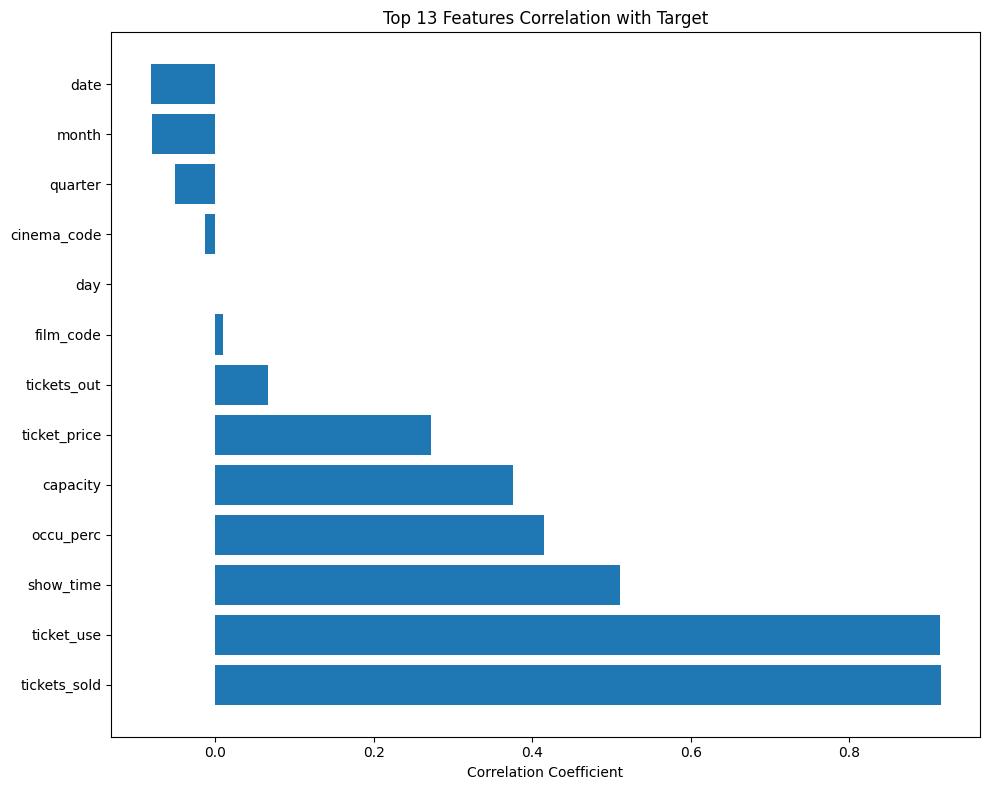


Jumlah fitur terpilih (|correlation| > 0.3): 5
Fitur terpilih: ['tickets_sold', 'ticket_use', 'show_time', 'occu_perc', 'capacity']

Shape dataset setelah seleksi: (142399, 6)


In [ ]:
## A. Correlation-Based Selection

# Calculate correlation with target
df_with_target = X.copy()
df_with_target['target'] = y

correlation = df_with_target.corr()['target'].sort_values(ascending=False)

print(“Feature correlation with target:”)
print(correlation)

# Visualize correlation
plt.figure(figsize=(10, 8))
top_features = min(15, len(correlation)-1)  # take max 15 or all if less
plt.barh(correlation.index[1:top_features+1], correlation.values[1:top_features+1])
plt.xlabel('Correlation Coefficient')
plt.title(f'Top {top_features} Features Correlation with Target')
plt.tight_layout()
plt.show()

# Select features with correlation > threshold
threshold = 0.3  # adjust threshold as needed
selected_features = correlation[abs(correlation) > threshold].index.tolist()
if 'target' in selected_features:
    selected_features.remove('target')

print(f"\nNumber of selected features (|correlation| > {threshold}): {len(selected_features)}")
print("Selected features:", selected_features)

# New dataset with selected features
df_selected = df_with_target[selected_features + ['target']]
print(f"\nShape of dataset after selection: {df_selected.shape}")



To determine which features are worth keeping, we look at their correlation values:

- Values close to 1 (Positive Correlation): “Proportional.” If the feature value increases, the target usually increases as well. Example: The greater the seating capacity, the higher the total sales.

- Values close to -1 (Negative Correlation): “Opposite”. If the feature value increases, the target actually decreases. Example: The more expensive the ticket price, the fewer the number of viewers.

- Values close to 0: “Irrelevant”. This feature has no clear effect on the target. This is the feature we should discard.

> Important: We usually set a threshold. For example, we only take features that have a correlation value above 0.3 or below -0.3. Features in between are considered “noise” that can slow down the computer and reduce the accuracy of the model.

### **B. Chi-Square Test**



**What is the Chi-Square Test?** If correlation is used to examine the relationship between numbers (such as ticket prices and income), Chi-Square is used to examine the relationship between group or category data.

This test seeks to determine: “Does this feature have a strong relationship with the target, or is the relationship merely coincidental?”

A simple analogy: “Movie Genres and Types of Snacks” Imagine you want to know if there is a relationship between the movie genres people watch and the types of snacks they buy.

- If horror movie viewers always buy salty popcorn, while romantic movie viewers always buy chocolate, then there is a strong relationship between genre and snack (high Chi-Square score).

- However, if horror, romantic, and action movie viewers all buy snacks randomly (no pattern), then there is no relationship (low Chi-Square score).

In [ ]:
## B. Chi-Square Test

from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler

# Normalize data to non-negative values (chi2 requirement)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Apply Chi-Square test to select the 10 best features
k_features = min(10, X.shape[1])  # select 10 or less if features < 10
chi2_selector = SelectKBest(chi2, k=k_features)
X_chi2 = chi2_selector.fit_transform(X_scaled, y)

# View the selected features
selected_features_idx = chi2_selector.get_support(indices=True)
selected_feature_names = X.columns[selected_features_idx].tolist()

print(f“\nFeatures selected with Chi-Square Test (top {k_features}):”)
print (selected_feature_names)

# View each feature's score
chi2_scores = pd.DataFrame({
    'Feature': X.columns,
    'Chi2_Score': chi2_selector.scores_
}).sort_values('Chi2_Score', ascending=False)

print(“\nChi-Square Scores:”)
print(chi2_scores.head(15))


Fitur terpilih dengan Chi-Square Test (top 10):
['film_code', 'cinema_code', 'tickets_sold', 'tickets_out', 'show_time', 'occu_perc', 'ticket_use', 'capacity', 'date', 'day']

Chi-Square Scores:
         Feature    Chi2_Score
5      occu_perc  11183.736080
2   tickets_sold   8914.656105
8       capacity   4038.308981
4      show_time   3435.968854
7     ticket_use   3364.344313
3    tickets_out   3060.959750
1    cinema_code   3024.662755
0      film_code   2541.470580
9           date   2329.865409
12           day   1725.053221
11       quarter   1723.346981
10         month   1703.146220
6   ticket_price   1001.651413


Explanation:

**Why use MinMaxScaler?** Chi-Square is like a scale that cannot accept negative values. Therefore, we must ensure that all our data is 0 or higher (non-negative) before testing.

What does the Chi2 Score mean?

- The higher the score: This means that the feature has a strong “inner connection” with the target. This feature is very important to keep because it can help the model predict more accurately.

- The lower the score: This means that the feature is indifferent to the target. Removing this feature will usually not hurt your model's performance.

> When to Use This? Use Chi-Square if you have a lot of categorical data (such as: Member Type, Movie Theater Location, Screening Day) and want to know which ones most determine the final outcome (such as: Popular or Not).

### **C. Variance Threshold**



**What is Variance Threshold?** In the world of data, **“variance”** is a measure of how diverse the contents of a column are. If a column contains almost identical contents (for example, 99% of rows contain the same number), then that feature is considered to provide no information for the machine to learn.

A Simple Analogy: “Movie Audience Survey” Imagine you are conducting a survey of 1,000 movie audience members to predict whether they will buy popcorn. You ask two questions:

- Are you human? (99% answer: Yes) -> Low Variance. This answer is useless because everyone gives the same answer. You cannot distinguish popcorn buyers from this question alone.

- How old are you? (Answers vary: 15, 25, 40, 60) -> High variance. This data is useful because age differences may determine who likes to buy popcorn and who doesn't.

**Variance Threshold** serves to discard the first type of “boring” questions because their content is uniform.

In [ ]:
## C. Variance Threshold

from sklearn.feature_selection import VarianceThreshold

# Calculate the variance of each feature
variances = X.var().sort_values(ascending=False)

print(“\nVariance of each feature:”)
print(variances)

# Set the variance threshold
var_threshold = 0.1  # adjust the threshold
selector = VarianceThreshold(threshold=var_threshold)

X_high_variance = selector.fit_transform(X)

# Features that pass the threshold
selected_features_var = X.columns[selector.get_support()].tolist()

print(f"\nNumber of features with variance > {var_threshold}: {len(selected_features_var)}")
print("Selected features:", selected_features_var)



Variance setiap fitur:
ticket_price    1.104723e+09
capacity        9.084341e+05
tickets_sold    7.823722e+04
ticket_use      7.812869e+04
cinema_code     2.548841e+04
date            4.217073e+03
film_code       1.309294e+03
occu_perc       5.131786e+02
day             8.007812e+01
show_time       9.344348e+00
tickets_out     8.551126e+00
month           4.818245e+00
quarter         6.551479e-01
dtype: float64

Jumlah fitur dengan variance > 0.1: 13
Fitur terpilih: ['film_code', 'cinema_code', 'tickets_sold', 'tickets_out', 'show_time', 'occu_perc', 'ticket_price', 'ticket_use', 'capacity', 'date', 'month', 'quarter', 'day']


Explanation :

**Why Are Certain Features Missing?** If certain features are missing after running the algorithm, it means that those features are too uniform. The machine considers those features to be a computational “burden” without providing meaningful clues for prediction.

Determining the Threshold Value:

- If Threshold = 0: We only discard features whose values are exactly the same across all rows.

- The higher the threshold value you provide, the more “aggressive” the filtering will be. Only features with high data diversity will be allowed to pass.

## **2. Wrapper Methods**



**What are Wrapper Methods?** If Filter Methods work like a sieve (looking only at data properties), Wrapper Methods work like an “audition.” We actually train the Machine Learning model and see how well it works with certain feature combinations.

This is much more accurate because features are selected based on actual performance, but it takes longer because the computer has to “learn” repeatedly.

A Simple Analogy: “Selecting a National Soccer Team”

- Filter Method: You select players based solely on height or running speed (statistics).

- Wrapper Method: You have the players compete directly on the field. You see who plays well with the team, then select the best based on the results of those matches.


### **A. Recursive Feature Elimination (RFE)**

**RFE** is an elimination system. It starts with all features, then discards the weakest ones one by one until the “Dream Team” (the best features) we want remains.

RFE analogy: “Survival Show (Example: MasterChef)”

1. In the first round, all participants (features) cook together.

2. The judges (ML Model) evaluate their performance.

3. The worst contestant is eliminated.

4. The next round begins with the remaining contestants, then another is eliminated.

5. This process is repeated until the top 10 best contestants remain.

In [ ]:
# ===========================
# 2. WRAPPER METHODS
# ===========================

## A. Recursive Feature Elimination (RFE)

from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd # Ensure pandas is imported for qcut

num_bins = 5 # You can adjust the number of bins as needed
y_binned = pd.qcut(y, q=num_bins, labels=False, duplicates='drop')

# Split data using the binned target for stratification
X_train, X_test, y_train_binned, y_test_binned = train_test_split(
    X, y_binned, test_size=0.3, random_state=42, stratify=y_binned
)

# Create model
model = LogisticRegression(max_iter=10000, random_state=42)

# Apply RFE to select 10 best features
n_features_to_select = min(10, X.shape[1])
rfe_selector = RFE(estimator=model, n_features_to_select=n_features_to_select, step=1)
rfe_selector.fit(X_train, y_train_binned) # Use binned target for fitting RFE

# Selected features
selected_features_rfe = X.columns[rfe_selector.support_].tolist()

print(f"\nFeatures selected with RFE (top {n_features_to_select}):")
print(selected_features_rfe)

# Feature ranking (1 = best)
feature_ranking = pd.DataFrame({
    'Feature': X.columns,
    'Ranking': rfe_selector.ranking_
}).sort_values('Ranking')

print(“\nFeature Ranking:”)
print(feature_ranking)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c


Fitur terpilih dengan RFE (top 10):
['film_code', 'cinema_code', 'tickets_sold', 'tickets_out', 'show_time', 'occu_perc', 'ticket_use', 'date', 'quarter', 'day']

Ranking Fitur:
         Feature  Ranking
0      film_code        1
1    cinema_code        1
2   tickets_sold        1
3    tickets_out        1
4      show_time        1
5      occu_perc        1
7     ticket_use        1
9           date        1
12           day        1
11       quarter        1
8       capacity        2
6   ticket_price        3
10         month        4


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Compare accuracy before and after RFE
# Model with all features
model_all = LogisticRegression(max_iter=10000, random_state=42)
model_all.fit(X_train, y_train_binned)
y_pred_all = model_all.predict (X_test)
acc_all = accuracy_score(y_test_binned, y_pred_all)

# Model with RFE features
X_train_rfe = rfe_selector.transform(X_train)
X_test_rfe = rfe_selector.transform(X_test)

model_rfe = LogisticRegression(max_iter=10000, random_state=42)
model_rfe.fit(X_train_rfe, y_train_binned)
y_pred_rfe = model_rfe.predict(X_test_rfe)
acc_rfe = accuracy_score(y_test_binned, y_pred_rfe)

print(f"\nAccuracy with all features ({X_train.shape[1]} features): {acc_all:.4f}")
print(f"Accuracy with RFE ({n_features_to_select} features): {acc_rfe:.4f}")
print(f"Difference: {acc_rfe - acc_all:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Akurasi dengan semua fitur (13 fitur): 0.8742
Akurasi dengan RFE (10 fitur): 0.7161
Selisih: -0.1581


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Explanation :

- Ranking 1: This means that the feature is the “core” of your data. It is never eliminated during the audition process.

- High Ranking (2, 3, etc.): This means that the feature is eliminated early because it is considered to be of little help to the model in making predictions.

**Why Does Accuracy Increase?** Often, too many features (noise) confuse the model. By removing unimportant features through RFE, our model becomes more “focused” and can provide more accurate predictions, or at least equally good predictions, but with less work.

### **B. Forward Selection**



**What is Forward Selection?** If RFE (Recursive Feature Elimination) works with an elimination system (starting with many and then reducing), Forward Selection works the opposite way. We start with an empty hand (0 features), then try each feature one by one and only include those that most improve the model's performance.

A Simple Analogy: “Building a Music Band”

- RFE: You call 50 musicians to the stage, then send the worst performers home one by one until you are left with the best band.

- Forward Selection: The stage is empty. You try one guitarist, then one drummer, then one vocalist. You only add personnel if the band sounds significantly better than before. If adding a pianist makes the sound chaotic, then the pianist is not invited.


In [ ]:
## B. Forward Selection

from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.ensemble import RandomForestClassifier

# Create model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Forward Selection
n_features_forward = min(10, X.shape[1])
forward_selector = SequentialFeatureSelector(
    rf_model,
    n_features_to_select=n_features_forward,
    direction='forward',
    scoring='accuracy',
    cv=5
)

forward_selector.fit(X_train, y_train_binned)

# Selected features
selected_features_forward = X.columns[forward_selector.get_support()].tolist()

print(f"\nSelected features with Forward Selection (top {n_features_forward}):")
print(selected_features_forward)


Fitur terpilih dengan Forward Selection (top 10):
['cinema_code', 'tickets_sold', 'tickets_out', 'ticket_price', 'ticket_use', 'capacity', 'date', 'month', 'quarter', 'day']


Explanation:

**Why Use Random Forest?** In feature selection, we often use different models to see other perspectives. Random Forest is excellent for seeing which features have high “predictive power” (feature importance) in a non-linear way.

Why is the process slower? Because the computer must try:

1. Try Feature A -> Check Accuracy.

2. Try Feature B -> Check Accuracy.

3. Try (A + B) -> Check Accuracy.

    ... and so on until the best combination of 10 features is found.

**When to Use Forward Selection?** This method is ideal if you have thousands of features but suspect that only a few (e.g., just 5 or 10) are truly influential. Starting from scratch is far more efficient than eliminating one by one from thousands of features.

### **C. Backward Elimination**



**What is Backward Elimination?** If Forward Selection starts from zero and continues to add features, Backward Elimination is the opposite. We start by putting all the features into the model, then one by one the most useless features or those that worsen the model's performance will be discarded.

Simple analogy: “Carving a statue from stone”

- Forward Selection: Like building a house from bricks. You start with an empty lot, then add bricks one by one until the house is complete.

- Backward Elimination: Like a sculptor creating a statue. You start with a large block of stone (all features), then remove the unnecessary parts until a beautiful statue (the best features) is formed.


In [ ]:
## C. Backward Elimination

# Backward Elimination
backward_selector = SequentialFeatureSelector(
    rf_model,
    n_features_to_select=n_features_forward,
    direction='backward',
    scoring='accuracy',
    cv=5)


backward_selector.fit(X_train, y_train_binned)

# Selected features
selected_features_backward = X.columns[backward_selector.get_support()].tolist()

print(f"\nSelected features with Backward Elimination (top {n_features_forward}):")
print(selected_features_backward)


Fitur terpilih dengan Backward Elimination (top 10):
['film_code', 'cinema_code', 'tickets_sold', 'tickets_out', 'ticket_price', 'ticket_use', 'date', 'month', 'quarter', 'day']


Explanation:

**Why is it different from RFE?** You may ask, **“What is the difference between this and RFE?”**. Although similar, RFE discards features based on the model's internal weights (such as coefficient values), while Backward Elimination discards features by trial and error (removing one feature, checking the accuracy, and if the accuracy remains good, the feature can be discarded).

**When to Use This?** This method is excellent if you suspect that your features work together (have strong interactions). By including everything at the beginning, the model can see the big picture first before starting to remove the smallest ones.

> Time Note: This method is usually the slowest compared to others. Imagine the computer having to run the model multiple times with a very large number of features at the beginning of the process.

## **3. Embedded Methods**



**What are Embedded Methods?** If Filters work like sieves and Wrappers work like auditions, then Embedded Methods work like **“Natural Selection”**. Unuseful features will naturally fall away as the model learns. This is the best of both worlds: as accurate as Wrappers but as fast as Filters.


### **A. Lasso Regularization (L1)**


Lasso is a type of mathematical model that has a unique property: it is very stingy. It imposes a “penalty” or tax on features that do not make a real contribution. If a feature is considered unimportant, Lasso will force its importance value (coefficient) to zero.

A Simple Analogy: “Packing Your Suitcase for Vacation” Imagine you want to go on vacation, but your suitcase is very small and there is a rule: “Every item you bring has a weight tax.”

- Clothes and Passport: Very important. Even though there is a weight tax, you still bring them because they are very useful.

- Spare Key Chain: Not very important. Because of the weight tax, you decide to leave it at home (its value becomes zero).

Lasso works like this weight tax rule; it forces you to only bring items that are truly essential.



Koefisien Lasso:
         Feature  Coefficient
2   tickets_sold     0.002037
8       capacity     0.000193
6   ticket_price     0.000012
0      film_code     0.000000
1    cinema_code     0.000000
4      show_time     0.000000
3    tickets_out     0.000000
5      occu_perc     0.000000
7     ticket_use     0.000000
9           date     0.000000
10         month     0.000000
11       quarter     0.000000
12           day     0.000000

Jumlah fitur terpilih: 3
Fitur terpilih: ['tickets_sold', 'capacity', 'ticket_price']


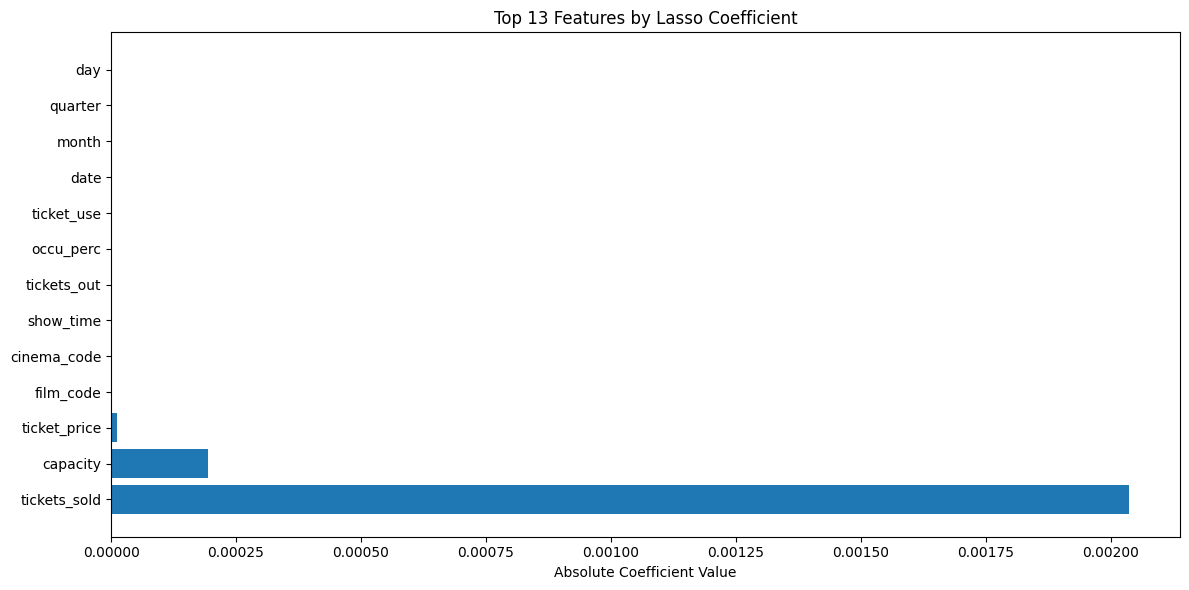

In [ ]:
# ===========================
# 3. EMBEDDED METHODS
# ===========================

## A. Lasso Regularization (L1)

from sklearn.linear_model import LassoCV

# Use LassoCV for auto-tuning alpha
lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso.fit(X_train, y_train_binned)

# Feature coefficients
lasso_coef = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': abs(lasso.coef_)
}).sort_values('Coefficient', ascending=False)

print(“\nLasso coefficients:”)
print(lasso_coef)

# Features with coefficients != 0
selected_features_lasso = lasso_coef[lasso_coef['Coefficient'] > 0]['Feature'].tolist()

print(f"\nNumber of selected features: {len(selected_features_lasso)}")
print("Selected features:", selected_features_lasso)

# Visualization
top_n = min(15, len(lasso_coef))
plt.figure(figsize=(12, 6))
plt.barh(lasso_coef['Feature'][:top_n], lasso_coef['Coefficient'][:top_n])
plt.xlabel('Absolute Coefficient Value')
plt.title(f'Top {top_n} Features by Lasso Coefficient')
plt.tight_layout()
plt.show()

Explanation:

**1. Why Are Some Features Missing?**  If you see features that do not appear in the graph or list, it is because Lasso has assigned a value of 0 to those features. This means that, according to Lasso's mathematics, those features are “junk” that only add to the model's load.

**2. Key Advantage:** Lasso is great because it does two jobs at once: it builds a model and selects features. You don't have to bother with separate feature selection.

**3. When to Use It:** Lasso is very effective if you have many features that are interrelated (multicollinearity). It will tend to select the best one and reject the others.

### **B. Ridge Regularization (L2)**



**What is Ridge Regularization?** If Lasso (L1) is “harsh” by directly discarding unimportant features (making them zero), Ridge (L2) is more “wise.” Ridge does not discard features at all, but rather minimizes the influence (coefficient) of features that are considered less important so as not to damage the prediction.

Simple analogy: “Dimming the Lights (Dimmer Switch)” Imagine you are on a theater stage with 50 spotlights (features).

- Lasso (L1): Will immediately turn off (switch OFF) the dim lights or those not focused on the actors.

- Ridge (L2): Does not turn off any lights, but it will dim the unimportant lights and only allow the main lights to remain bright. All lights remain on, but their influence varies.

In [ ]:
## B. Ridge Regularization (L2)

from sklearn.linear_model import RidgeCV

# Ridge Regression
ridge = RidgeCV(cv=5)
ridge.fit(X_train, y_train_binned)

# Feature coefficients
ridge_coef = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': abs(ridge.coef_)
}).sort_values('Coefficient', ascending=False)

print("\nTop 15 features based on Ridge Coefficient:")
print(ridge_coef.head(15))

# Select top-k features
k = min(10, len(ridge_coef))
selected_features_ridge = ridge_coef.head(k)['Feature'].tolist()
print(f"\nTop {k} selected features:", selected_features_ridge)


Top 15 fitur berdasarkan Ridge Coefficient:
         Feature  Coefficient
10         month     1.590973
11       quarter     0.316840
4      show_time     0.062857
12           day     0.047616
9           date     0.045576
5      occu_perc     0.035593
0      film_code     0.004325
1    cinema_code     0.000613
8       capacity     0.000388
3    tickets_out     0.000345
2   tickets_sold     0.000200
7     ticket_use     0.000145
6   ticket_price     0.000011

Top 10 fitur terpilih: ['month', 'quarter', 'show_time', 'day', 'date', 'occu_perc', 'film_code', 'cinema_code', 'capacity', 'tickets_out']


Explanation:

**1. Why are there no zero coefficients?** This is the inherent nature of Ridge. It believes that every piece of information (feature) may have a small contribution, so it does not discard it. It only suppresses the values of “noisy” features so that their values are very small, close to zero, but never actually zero.

**2. When to Use Ridge?** Use Ridge if you feel that all features in your dataset play an important role and you don't want to lose any information, but you want your model to be less sensitive to unstable data.

**3. Comparison of Lasso vs. Ridge:**

- Lasso: Good for simplifying the model (discarding features).

- Ridge: Good for handling closely related data (multicollinearity) without having to discard features.

### **C. Tree-Based Feature Importance**



**What is Tree-Based Importance?** Models such as Random Forest work by creating hundreds of “Decision Trees.” Each tree will ask the data: “Is the ticket price expensive?” or “Is it a holiday?”

The features that are most often used to make accurate decisions will receive a high Importance score.

A Simple Analogy: “Asking 100 Strategy Experts” Imagine you want to know the most decisive factor in determining whether a movie will be a box office hit. You ask 100 cinema experts (Random Forest).

- Each expert will note down the factors they use to make their guess (e.g., Actor Name, Genre, or Duration).

- If almost all experts consistently ask “Who is the lead actor?” to give the correct answer, then the “Actor” feature is considered to have very high Importance.

- If the “Poster Color” feature is rarely asked or does not help them guess correctly, then its importance score will be very low.


Feature Importance (Random Forest):
         Feature  Importance
2   tickets_sold    0.286789
7     ticket_use    0.264309
6   ticket_price    0.247300
5      occu_perc    0.075567
8       capacity    0.042160
4      show_time    0.026292
1    cinema_code    0.021716
9           date    0.012285
0      film_code    0.008561
12           day    0.007453
10         month    0.004462
11       quarter    0.001597
3    tickets_out    0.001510


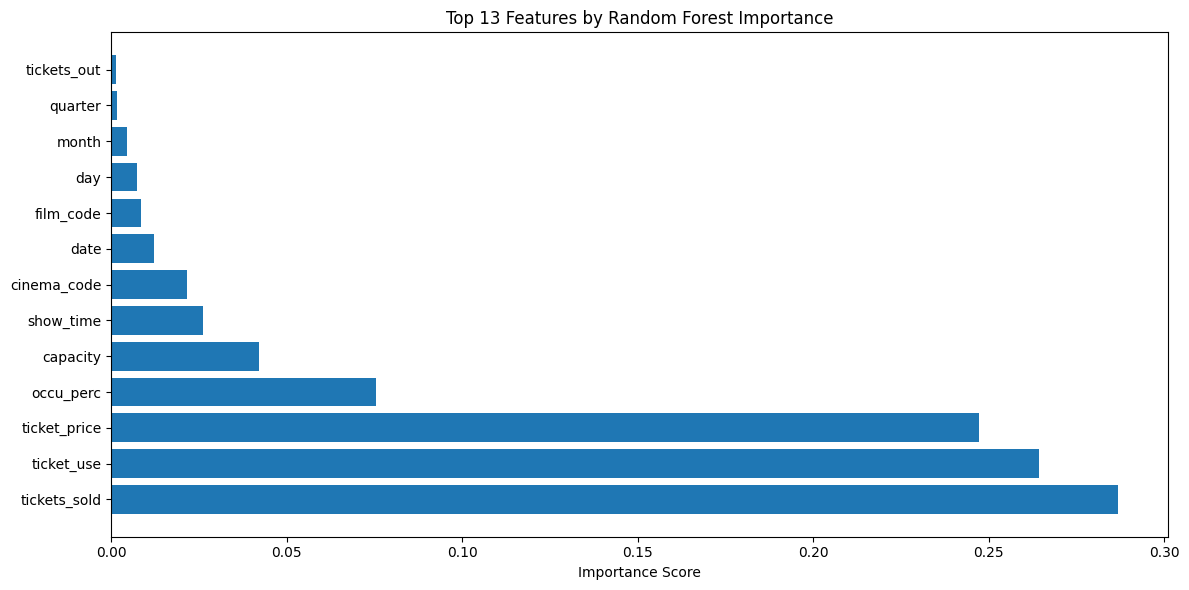


Fitur dengan importance > 0.01: 8
['tickets_sold', 'ticket_use', 'ticket_price', 'occu_perc', 'capacity', 'show_time', 'cinema_code', 'date']


In [ ]:
## C. Tree-Based Feature Importance

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train_binned)

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
    }).sort_values('Importance', ascending=False)

print("\nFeature Importance (Random Forest):")
print(feature_importance)

# Visualization
top_n_importance = min(15, len(feature_importance))
plt.figure(figsize=(12, 6))
plt.barh(feature_importance['Feature'][:top_n_importance],
feature_importance['Importance'][:top_n_importance])
plt.xlabel('Importance Score')
plt.title(f'Top {top_n_importance} Features by Random Forest Importance')
plt.tight_layout()
plt.show()

# Select features with importance > threshold
threshold_importance = 0.01
selected_features_rf = feature_importance[
feature_importance['Importance'] > threshold_importance
]['Feature'].tolist()

print(f"\nFeatures with importance > {threshold_importance}: {len(selected_features_rf)}")
print(selected_features_rf)

Explanation:

**1. Why Use This?** Unlike correlation, which only looks at linear relationships, Random Forest can see complex relationships. For example, ticket prices may not be important on their own, but they become very important when combined with the location of the cinema.

**2. How to Read the Scores:** All importance scores add up to 1.0 (100%). So, if a feature has a score of 0.2, it means that feature contributes 20% to the model's decision-making power.

**3. Threshold:** We usually discard features with very small scores (e.g., below 0.01) because they are considered “spectators” that do not contribute significantly to the prediction.

## **4. Comparison of Feature Selection Methods**



The following is a comparison between several Feature Selection Methods:

| **Method**   | **Evaluation Criteria**               | **Advantages**     | **Disadvantages** |
| -------- | ------------------------------- | ---------     | ---------- |
| Filter   | Correlation/independent statistics   | Fast, easy to apply | Does not consider feature interactions |
| Wrapper  | Evaluation with model algorithms | Considers feature interactions | Computationally expensive |
| Embedded | Selection during model training | Integrated and efficient | Dependent on the model |




---



# **C. DIMENSIONALITY REDUCTION**

What is the difference with Feature Selection? If Feature Selection is like choosing the 5 best spices from the spice rack, then Dimensionality Reduction is like putting all the spices in a blender and making a spoonful of secret spice paste. It contains the essence of all the original spices, but its form has changed and is much more concise.

## **1. Principal Component Analysis (PCA)**



PCA is a technique for summarizing data that has many columns into just a few new columns (called Principal Components) without losing too much important information.

Simple analogy: “Photographing a 3D object” Imagine you have a statue (3D data: length, width, height). You want to describe the shape of the statue to a friend through a photo (2D).

- You will look for the best photo angle (Principal Component) where the entire shape of the sculpture is most clearly visible and not much of it is covered.

- The photo has lost the “depth” dimension, but because you took the right angle, your friend still knows what the sculpture is. That is PCA: projecting data into a lower dimension from the most informative perspective.


In [ ]:
# ===========================
# C. DIMENSIONALITY REDUCTION
# ===========================

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn. decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# ===========================
# PREPROCESSING FOR DIMENSIONALITY REDUCTION
# ===========================

# Create a copy of the dataframe for preprocessing
df_processed = df.copy()

# Check and handle missing values
print("Missing values ​​before preprocessing:")
print(df_processed.isnull().sum())
df_processed = df_processed.dropna()

# Identify categorical and numeric columns
categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df_processed.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("\nCategorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

# Encode categorical features
le = LabelEncoder()
for col in categorical_cols:
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))

# DETERMINE A VARIABLE TARGET
# For LDA to work correctly, the target variable (y) must be categorical with a reasonable number of classes.
# The 'total_sales' column is continuous. We will bin it to create a suitable target.
if 'total_sales' in df_processed.columns:
    # Bin 'total_sales' into a smaller, manageable number of categories
    num_bins = 5 # Adjust the number of bins as needed for your problem
    # Using qcut to create bins with approximately equal numbers of observations
    # 'duplicates=\'drop\'' handles cases where quantile boundaries might be identical
    df_processed['total_sales_binned_for_dr'] = pd.qcut(
    df_processed['total_sales'],
    q=num_bins,
    labels=False,
    duplicates='drop'
)
target_column_for_dr = 'total_sales_binned_for_dr'
else:
    # Fallback if 'total_sales' column is unexpectedly missing
    # This part might need further refinement based on the specific dataset
    print("Warning: 'total_sales' column not found for binning. Using first numerical column.")
    if len(numerical_cols) > 0:
    df_processed['generic_binned_target_for_dr'] = pd.qcut(
    df_processed[numerical_cols[0]],
    q=5,
    labels=False,
    duplicates='drop'
)
target_column_for_dr = 'generic_binned_target_for_dr'
else:
    # As a last resort, use the first column as target (might not be suitable for LDA)
    target_column_for_dr = df_processed.columns[0]

    print(f"\nTarget column used for Dimensionality Reduction: {target_column_for_dr}")
    print(f"Target distribution:\n{df_processed[target_column_for_dr].value_counts()}")

    # Data preparation
    # Drop the *original* continuous 'total_sales' column from features if it's not the new target
    columns_to_drop_from_X = [target_column_for_dr]
if 'total_sales' in df_processed.columns and 'total_sales' != target_column_for_dr:
    columns_to_drop_from_X.append('total_sales')

X = df_processed.drop(columns=columns_to_drop_from_X, errors='ignore')
y = df_processed[target_column_for_dr]

# Standardization (important for PCA and LDA!) - RE-APPLY AFTER X AND Y ARE REDEFINED
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nShape X (after target binning and re-definition): {X.shape}")
print(f"Shape y (after target binning and re-definition): {y.shape}")
print(f"Shape X_scaled (after target binning and re-definition): {X_scaled.shape}")

Missing values sebelum preprocessing:
film_code       0
cinema_code     0
total_sales     0
tickets_sold    0
tickets_out     0
show_time       0
occu_perc       0
ticket_price    0
ticket_use      0
capacity        0
date            0
month           0
quarter         0
day             0
dtype: int64

Kolom kategorikal: []
Kolom numerik: ['film_code', 'cinema_code', 'total_sales', 'tickets_sold', 'tickets_out', 'show_time', 'occu_perc', 'ticket_price', 'ticket_use', 'capacity', 'date', 'month', 'quarter', 'day']

Target column yang digunakan untuk Dimensionality Reduction: total_sales_binned_for_dr
Distribusi target:
total_sales_binned_for_dr
0    28537
2    28520
4    28477
1    28454
3    28411
Name: count, dtype: int64

Shape X (after target binning and re-definition): (142399, 13)
Shape y (after target binning and re-definition): (142399,)
Shape X_scaled (after target binning and re-definition): (142399, 13)


In [ ]:
# ===========================
# 1. PRINCIPAL COMPONENT ANALYSIS (PCA)
# ===========================

# Apply PCA
n_components_initial = min(5, X.shape[1]) # take 5 or less if features < 5
pca = PCA(n_components=n_components_initial)
X_pca = pca.fit_transform(X_scaled)

print(f"Shape after PCA: {X_pca.shape}")
print("\nVariance explained by each component:")
print(pca.explained_variance_ratio_)
print("\nCumulative variance explained:")
print(np.cumsum(pca.explained_variance_ratio_))

Shape setelah PCA: (142399, 5)

Variance explained by each component:
[0.29159061 0.22728028 0.11981105 0.07865856 0.07640325]

Cumulative variance explained:
[0.29159061 0.51887089 0.63868194 0.7173405  0.79374375]


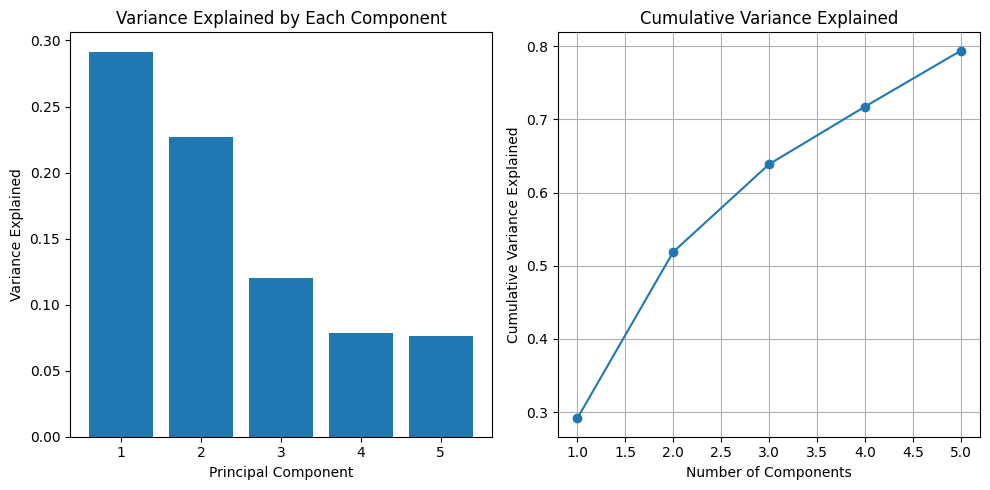

In [ ]:
# Visualization of explained variance
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.bar(range(1, n_components_initial + 1), pca.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('Variance Explained by Each Component')

plt.subplot(1, 2, 2)
plt.plot(range(1, n_components_initial + 1), np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.title('Cumulative Variance Explained')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Determine the number of components to capture 95% of the variance
pca_full = PCA()
pca_full.fit(X_scaled)

cumsum_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumsum_variance >= 0.95) + 1

print(f"\nNumber of components for 95% variance: {n_components_95}")
print(f"Of the total {X.shape[1]} original features")

# Apply PCA with optimal components
pca_optimal = PCA(n_components=n_components_95)
X_pca_optimal = pca_optimal.fit_transform(X_scaled)

print(f"\nReduction: {X.shape[1]} -> {n_components_95} features")
print(f"Variance retained: {cumsum_variance[n_components_95-1]:.2%}")


Jumlah komponen untuk 95% variance: 8
Dari total 13 fitur original

Reduction: 13 -> 8 features
Variance retained: 95.91%


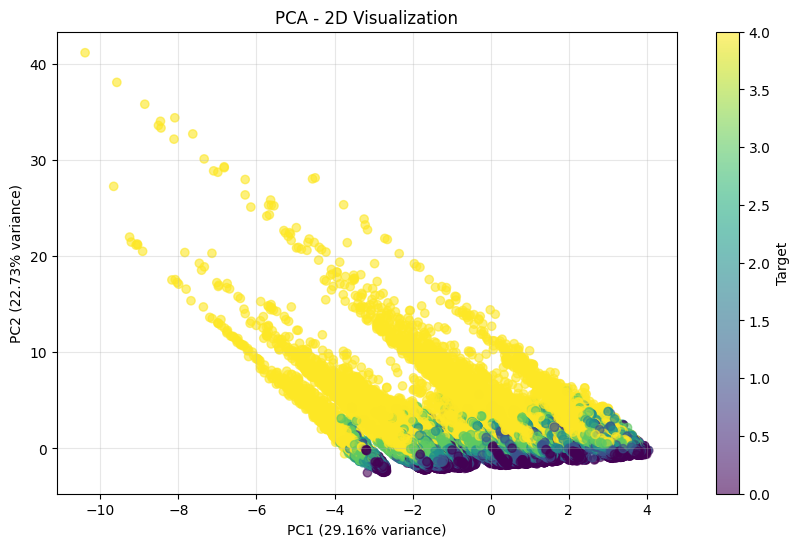


Kontribusi fitur terhadap Principal Components:
     film_code  cinema_code  tickets_sold  tickets_out  show_time  occu_perc  \
PC1   0.444897     0.044553     -0.152025    -0.017898  -0.077955  -0.133246   
PC2   0.168515    -0.113424      0.509012     0.061967   0.437869   0.210077   
PC3   0.009209     0.501956      0.210648     0.040723  -0.279216   0.573588   
PC4   0.097979     0.123088     -0.065473     0.293685   0.096420  -0.061313   
PC5  -0.029719     0.068229     -0.022687     0.936883   0.014368  -0.049269   

     ticket_price  ticket_use  capacity      date     month   quarter  \
PC1      0.021098   -0.151944 -0.067881  0.494676  0.497243  0.477879   
PC2      0.120499    0.508718  0.381808  0.109662  0.111693  0.125463   
PC3      0.089741    0.210368 -0.484689  0.022886  0.029573  0.059943   
PC4      0.484553   -0.068591 -0.036011  0.060108 -0.045379 -0.068424   
PC5     -0.268713   -0.032505  0.032027 -0.013581  0.012641  0.017628   

          day  
PC1 -0.065994  

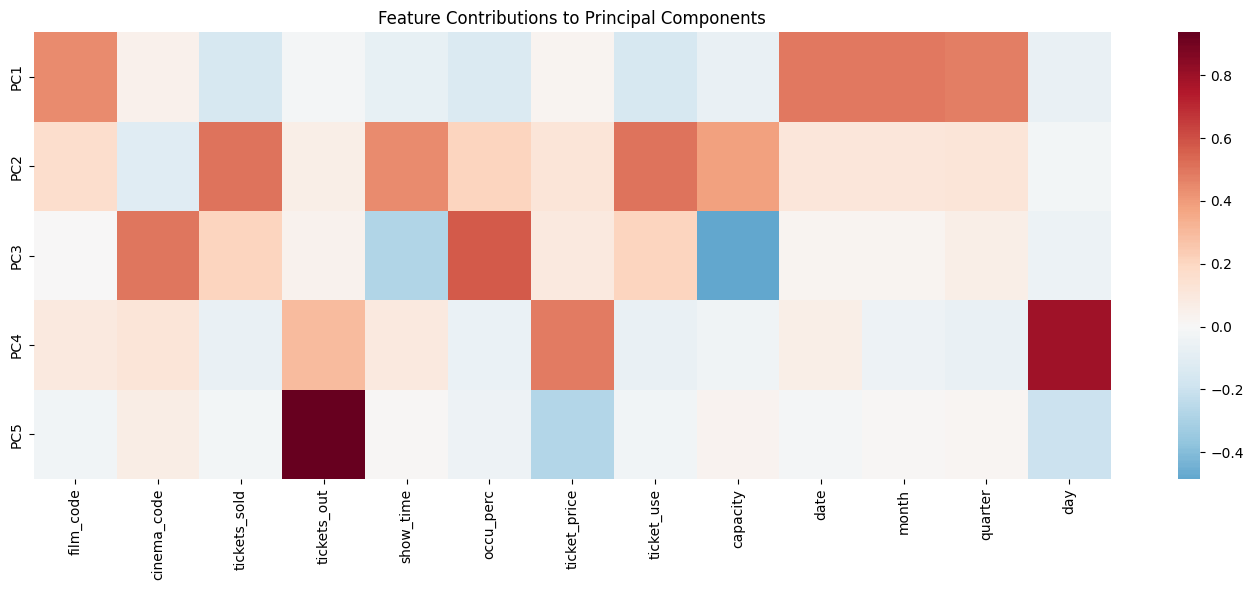

In [ ]:
# 2D Visualization
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='viridis', alpha=0.6)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} variance)')
plt.title('PCA - 2D Visualization')
plt.colorbar(scatter, label='Target')
plt.grid(True, alpha=0.3)
plt.show()

# See original feature contributions to PC
components_df = pd.DataFrame(
pca.components_,
columns=X.columns,
index=[f'PC{i+1}' for i in range(n_components_initial)]
)

print("\nFeature contribution to Principal Components:")
print(components_df)

# Heatmap visualization
plt.figure(figsize=(14, 6))
sns.heatmap(components_df, cmap='RdBu_r', center=0, annot=False, cbar=True)
plt.title('Feature Contributions to Principal Components')
plt.tight_layout()
plt.show()

Explanation:

- Principal Components (PC1, PC2, etc.): These are new features created by PCA. PC1 always carries the most information (variance), PC2 the second most, and so on.

- Cumulative Variance: See the orange line graph. If you can capture > 90% of the information with just 2 components, then you no longer need to use dozens of original columns. Just use these two new columns for your model.

- Contribution Heatmap: This section shows the “recipe” for the pasta sauce. For example, PC1 may contain 80% of the ticket_price feature and 20% of the seat_capacity feature. This helps us understand the meaning of the new columns.

Note: PCA is an unsupervised method. This means that when summarizing data, it does not look at the target (y). It only focuses on finding the most variable features. If you want to summarize data while looking at the target, we will use LDA in the next section.

## **2. Linear Discriminant Analysis (LDA)**



**What is LDA?** If PCA looks for the “photo angle” that captures the most detail (variance), LDA looks for the “photo angle” that can best distinguish one group from another. LDA is a supervised method, meaning it must “see” the target label (y) in order to know how to neatly separate the data.

Simple analogy: “Separating a mixture of candies” Imagine that in front of you there is a mixture of red and blue marbles scattered on a table.

- PCA: Finds a way to arrange the marbles so that they are spread as far apart as possible and cover as much of the table as possible (focuses on dispersion/variance).

- LDA: Finding a boundary line on the table so that all the red marbles are grouped on the left and the blue marbles are grouped on the right. LDA focuses on maximizing the distance between groups and minimizing the distance within groups.

Jumlah kelas: 5
Maksimal komponen LDA yang dimungkinkan: 4
Shape setelah LDA: (142399, 4)

Variance explained by each Linear Discriminant:
[9.42733138e-01 5.65975906e-02 6.42804642e-04 2.64669079e-05]


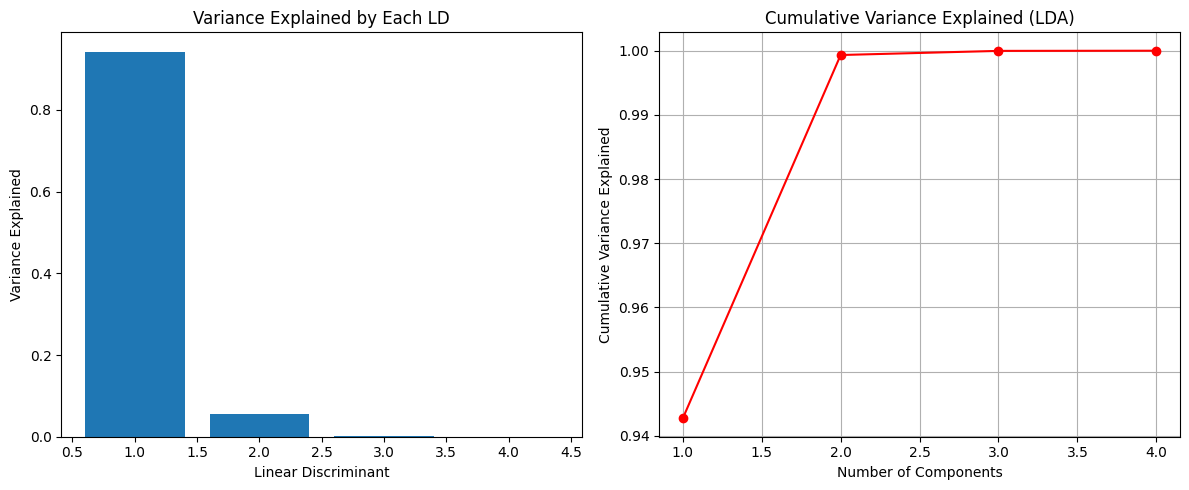

In [ ]:
# ============================
# 2. LINEAR DISCRIMINANT ANALYSIS (LDA)
# ==========================
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Note: The maximum LDA has n_components = (number_of_classes - 1)
n_classes = len(np.unique(y))
n_features = X.shape[1]
max_lda_components = min(n_features, n_classes - 1)

print(f"Number of classes: {n_classes}")
print(f"Maximum possible LDA components: {max_lda_components}")

# Apply LDA
lda = LinearDiscriminantAnalysis(n_components=max_lda_components)
X_lda = lda.fit_transform(X_scaled, y)

print(f"Shape after LDA: {X_lda.shape}")

# Visualization of explained variance (Discriminability)
if max_lda_components > 1:
    print("\nVariance explained by each Linear Discriminant:")
    print(lda.explained_variance_ratio_)

    plt.figure(figsize=(12, 5))

    # Plot 1: Individual Variance
    plt.subplot(1, 2, 1)
    plt.bar(range(1, len(lda.explained_variance_ratio_) + 1), lda.explained_variance_ratio_)
    plt.xlabel('Linear Discriminant')
    plt.ylabel('Variance Explained')
    plt.title('Variance Explained by Each LD')

    # Plot 2: Cumulative Variance
    plt.subplot(1, 2, 2)
    plt.plot(range(1, len(lda.explained_variance_ratio_) + 1), np.cumsum(lda.explained_variance_ratio_), marker='o', color='red')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Variance Explained')
    plt.title('Cumulative Variance Explained (LDA)')
    plt.grid(True)

    plt.tight_layout()
    plt.show()
else:
    print("\n[Info] There is only 1 component (because the target only has 2 classes/binaries).")

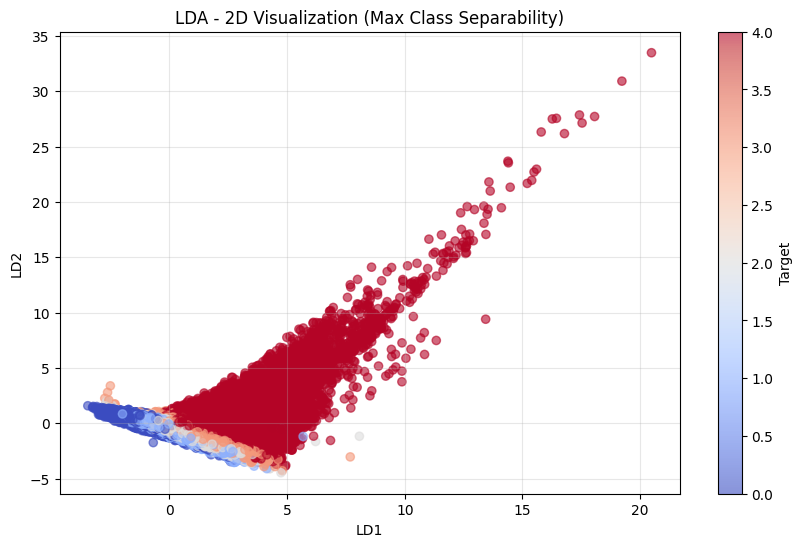

In [ ]:
# ===========================
# LDA Visualization (2D or 1D)
# ==========================

plt.figure(figsize=(10, 6))

if max_lda_components >= 2:
    # 2D plot if possible
    scatter = plt.scatter(X_lda[:, 0], X_lda[:, 1], c=y, cmap='coolwarm', alpha=0.6)
    plt.xlabel('LD1')
    plt.ylabel('LD2')
    plt.title('LDA - 2D Visualization (Max Class Separability)')
    plt.colorbar(scatter, label='Target')
else:
    # 1D plot if There are only 2 classes (Binary Classification)
    plt.scatter(X_lda[:, 0], np.zeros_like(X_lda[:, 0]), c=y, cmap='coolwarm', alpha=0.6)
    plt.xlabel('LD1')
    plt.title('LDA - 1D Visualization (Binary Class Separation)')
    plt.yticks([]) # Remove the Y-axis

plt.grid(True, alpha=0.3)
plt.show()


Kontribusi fitur terhadap Linear Discriminants (Scalings):
     film_code  cinema_code  tickets_sold  tickets_out  show_time  occu_perc  \
LD1   0.217213    -0.113851      0.131126    -0.002890   0.248346   1.087008   
LD2  -0.162190     0.200675      0.726823     0.003763  -0.236877  -0.879137   
LD3  -0.182035    -0.630489      0.102641     0.067965   0.045588  -0.626150   
LD4  -0.027614     0.390661     -0.087149    -0.316036   0.657687  -0.120818   

     ticket_price  ticket_use  capacity       date      month   quarter  \
LD1      0.526683    0.131235  0.503238   3.189958  -3.876754  0.318836   
LD2     -0.103248    0.727086 -0.405956  -7.468715   8.231308 -0.425791   
LD3      0.499718    0.101510 -0.151917  17.242129 -18.172489  0.744220   
LD4      0.494424   -0.081715 -0.523885  24.971302 -24.864777 -0.176068   

          day  
LD1 -0.468683  
LD2  1.036733  
LD3 -2.175945  
LD4 -3.243955  


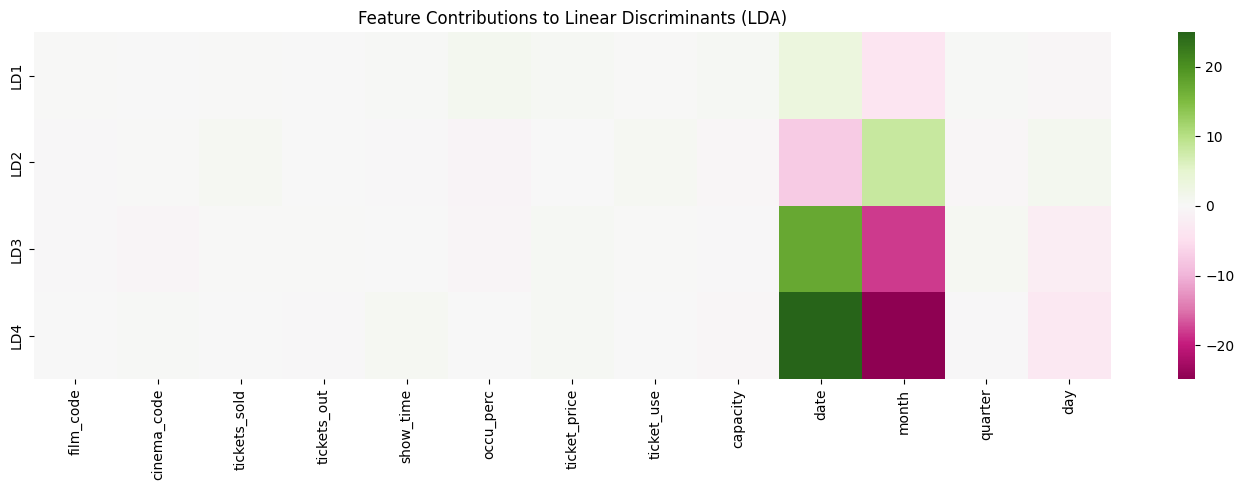

In [ ]:
# ===========================
# FEATURE CONTRIBUTION TO LDA
# ==========================

# LDA coefficients indicate how important a feature is in distinguishing between classes

lda_components_df = pd.DataFrame(
    lda.scalings_.T,
    columns=X.columns,
    index=[f'LD{i+1}' for i in range(X_lda.shape[1])] # Use X_lda.shape[1] for the actual number of components
)

print("\nFeature Contribution to Linear Discriminants (Scalings):")
print(lda_components_df)

# Feature Contribution Heatmap Visualization
plt.figure(figsize=(14, 5))
sns.heatmap(lda_components_df, cmap='PiYG', center=0, annot=False)
plt.title('Feature Contributions to Linear Discriminants (LDA)')
plt.tight_layout()
plt.show()

Explanation:

**1. Class Separation:** Look at the LDA visualization results. If the color groups (categories) appear to be separated far apart from each other (not overlapping like PCA), it means that your original features do indeed have strong distinguishing patterns.

**2. Why is LDA Limited?** Mathematically, to separate n groups, you only need a maximum of n−1 dividing lines. That is why the number of LDA components is much smaller than the original features.

**3. When to Use LDA?** Use LDA if your main goal is to build a classification model. LDA will prepare new features that have been “cleaned up” so that your classification model can more easily recognize the differences between classes.

## **3. t-Distributed Stochastic Neighbor Embedding (t-SNE)**

**What is t-SNE?** Unlike PCA or LDA, which are linear (like viewing data from a straight angle), t-SNE is a non-linear method. Its main task is visualization. t-SNE works hard to ensure that data that are originally neighbors or similar in high dimensions remain neighbors when transferred to a 2D map.

A simple analogy: “Peeling an orange” Imagine you have an orange whose skin is drawn on a map of the world (the earth is round/3D). You want to transfer the map onto flat paper (2D).

- If you force it linearly, the map will tear or the shape of the continents will become distorted.

- t-SNE works like carefully peeling the orange skin, then stretching and sticking it piece by piece onto the paper so that the continents that were originally neighbors remain close together.

In [ ]:
# ============================
# 3. t-Distributed Stochastic Neighbor Embedding (t-SNE)
# ==========================
from sklearn.manifold import TSNE
import time

# t-SNE is very sensitive to data size.
# If your dataset is > 10,000 rows, consider using a subset.

MAX_SAMPLES = 5000
if len(X_scaled) > MAX_SAMPLES:
    print(f"[Warning] Data is quite large. Using a subset of {MAX_SAMPLES} samples for efficiency.")
    X_for_tsne = X_scaled[:MAX_SAMPLES]
    y_for_tsne = y[:MAX_SAMPLES]
else:
    X_for_tsne = X_scaled
    y_for_tsne = y

print("Running t-SNE... (please wait)")
start_time = time.time()

# Apply t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto', # 'auto' often produces more stable results in newer versions of sklearn
    n_iter=1000,
    init='pca', # Using initialization PCA produces more stable results
    (random_state=42)
)

X_tsne = tsne.fit_transform(X_for_tsne)
end_time = time.time()

print(f"Completed in: {end_time - start_time:.2f} seconds")
print(f"Kullback-Leibler (KL) divergence: {tsne.kl_divergence_:.4f}")

[Peringatan] Data cukup besar. Menggunakan subset 5000 sampel untuk efisiensi.
Menjalankan t-SNE... (mohon tunggu)
Selesai dalam: 48.30 detik
Kullback-Leibler (KL) divergence: 1.0905


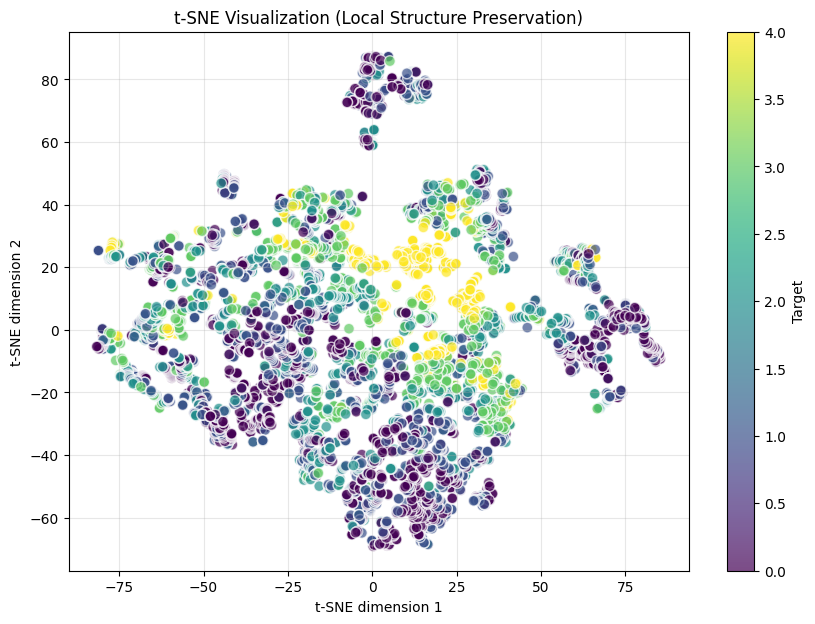

In [ ]:
# t-SNE Main Visualization
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y_for_tsne,
    cmap='viridis',
    alpha=0.7,
    edgecolors='w',
    s=60
)
plt.title('t-SNE Visualization (Local Structure Preservation)')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.colorbar(scatter, label='Target')
plt.grid(True, alpha=0.3)
plt.show()


Mengevaluasi berbagai nilai perplexity...


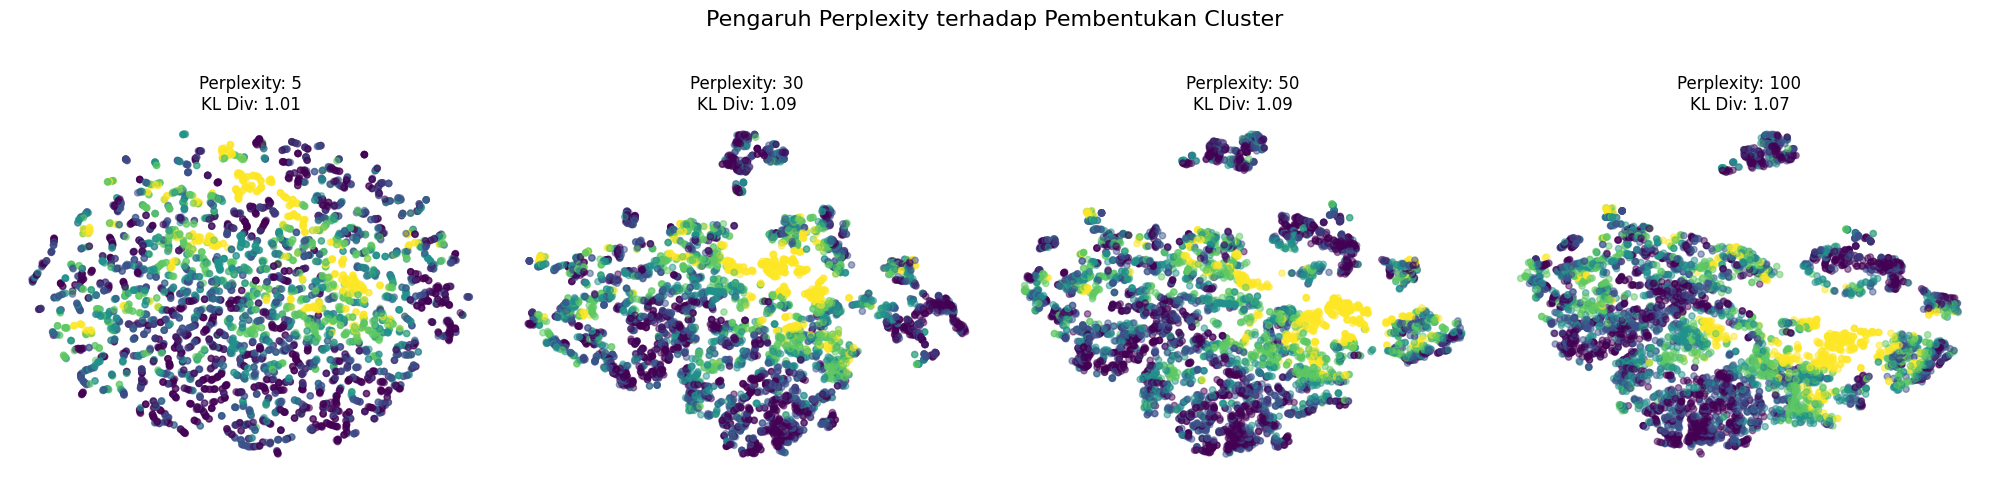

In [ ]:
# ============================
# PERPLEXITY EXPERIMENT
# ==========================
# Perplexity can be thought of as an estimate of the number of nearest neighbors for each point.

perplexities = [5, 30, 50, 100]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

print("\nEvaluating various perplexity values...")

for i, perp in enumerate(perplexities):
    tsne_loop = TSNE(n_components=2, perplexity=perp, random_state=42, init='pca', n_iter=1000)
    X_loop = tsne_loop.fit_transform(X_for_tsne)

    ax = axes[i]
    ax.scatter(X_loop[:, 0], X_loop[:, 1], c=y_for_tsne, cmap='viridis', alpha=0.5, s=20)
    ax.set_title(f'Perplexity: {perp}\nKL Div: {tsne_loop.kl_divergence_:.2f}')
    ax.axis('off')

plt.suptitle('The Effect of Perplexity on Cluster Formation', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Explanation of Results for the Module:

**1. Cluster:** If you see separate clusters on the graph, it means that t-SNE has successfully found groups of data that have similar properties. The closer the distance between two points, the more similar the two data points are.

**2. KL Divergence:** You will see this value in the code output. Think of it as an “Error Score.” The lower the value, the more successfully t-SNE has moved the data to a 2D map without damaging the relationships between neighbors.

**3. Perplexity:** This is the most important parameter in t-SNE.

- Low Perplexity (e.g., 5): t-SNE only cares about very close neighbors (the result will look like small scattered dots).

- High Perplexity (e.g., 50): t-SNE looks at the big picture (the result will form larger, more cohesive clusters).

## 4. Comparison of PCA vs LDA vs t-SNE

The following is a comparison of the three methods of Dimensionality Reduction:

| Aspect | PCA | LDA | t-SNE |
|-------|-----|-----|-------|
| **Type** | Unsupervised | Supervised | Unsupervised |
| **Linear** | Yes | Yes | No |
| **Purpose** | Maximize variance | Maximize class separation | Preserve local structure |
| **Speed** | Fast | Fast | Slow |
| **Interpretability** | Moderate | High | Low |
| **New data transformation** | Yes | Yes | No |
| **Use case** | Compression, noise reduction | Classification | Visualization |


---

# **CODELAB (20%)**



In this exercise, you will perform feature selection and dimensionality reduction on the **Super Market Sales** dataset.




**Dataset: [Super Market Sales](https://drive.google.com/file/d/1YvfQ9e79z05EfE5TE_4nCE5gHGODdPT0/view?usp=sharing)**

---

**Alternative with Kaggle**

```python
import kagglehub
import shutil
import os

# 1. Download dataset
path = kagglehub.dataset_download(“akashbommidi/super-market-sales”)

# 2. Specify the destination folder name in /content
destination = “/content/super-market-sales”

# 3. Move or copy the folder
if not os.path.exists(destination):
    shutil.copytree(path, destination)
    print(f“The dataset has been successfully copied to: {destination}”)
else:
    print(“The folder is already in /content.”)

```

In [ ]:
import kagglehub
import shutil
import os

# 1. Download dataset
path = kagglehub.dataset_download("akashbommidi/super-market-sales")

# 2. Specify the destination folder name in /content
destination = "/content/super-market-sales"

# 3. Move or copy the folder
if not os.path.exists(destination):
    shutil.copytree(path, destination)
    print(f"The dataset has been successfully copied to: {destination}")
else:
    print("The folder is already in /content.")

Using Colab cache for faster access to the 'super-market-sales' dataset.
The folder is already in /content.


**Instruction :**

1. Perform Exploratory Data Analysis (EDA) **(15 points)**
   - Display descriptive statistics
   - Check for missing values
   - Visualize the distribution of the target variable (quality)
   - Create a correlation heatmap

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Load Dataset
# The dataset was copied to /content/super-market-sales/
csv_file_path = '/content/super-market-sales/supermarket_sales.csv'

try:
    df = pd.read_csv(csv_file_path)
    print(f"Dataset loaded successfully from: {csv_file_path}")
except FileNotFoundError:
    print(f"File not found. Please ensure the CSV file is at the correct path: {csv_file_path}")

Dataset loaded successfully from: /content/super-market-sales/supermarket_sales.csv


In [ ]:
# 1. Perform Exploratory Data Analysis (EDA)

# Display descriptive statistics
print("\nDescriptive Statistics:")
print(df.describe(include='all'))

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())



Descriptive Statistics:
         Invoice ID Branch    City Customer type  Gender         Product line  \
count          1000   1000    1000          1000    1000                 1000   
unique         1000      3       3             2       2                    6   
top     849-09-3807      A  Yangon        Member  Female  Fashion accessories   
freq              1    340     340           501     501                  178   
mean            NaN    NaN     NaN           NaN     NaN                  NaN   
std             NaN    NaN     NaN           NaN     NaN                  NaN   
min             NaN    NaN     NaN           NaN     NaN                  NaN   
25%             NaN    NaN     NaN           NaN     NaN                  NaN   
50%             NaN    NaN     NaN           NaN     NaN                  NaN   
75%             NaN    NaN     NaN           NaN     NaN                  NaN   
max             NaN    NaN     NaN           NaN     NaN                  NaN   

  

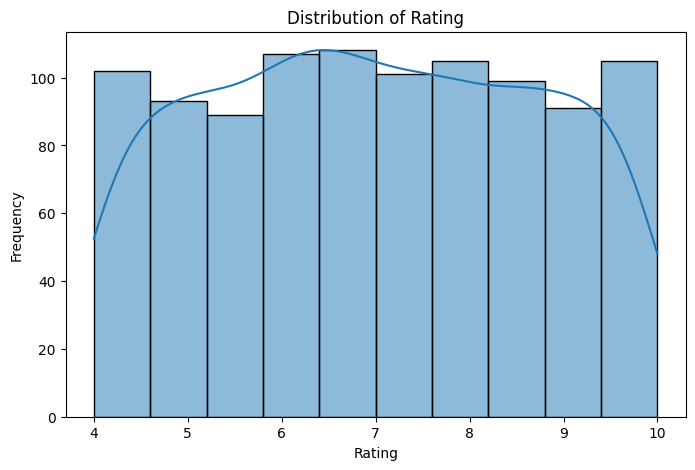

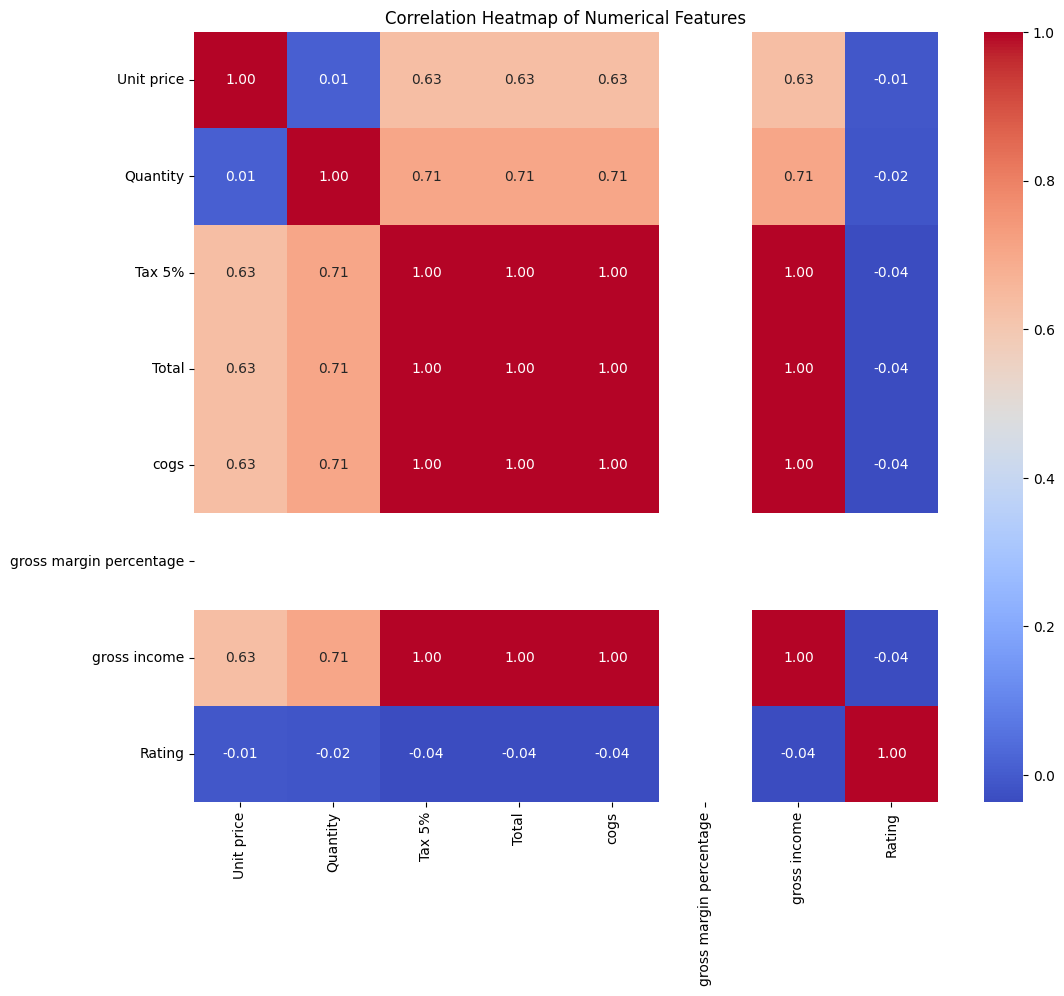

In [ ]:
# Visualize the distribution of the target variable (Rating)
plt.figure(figsize=(8, 5))
sns.histplot(df['Rating'], bins=10, kde=True)
plt.title('Distribution of Rating')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

# Create a correlation heatmap for numerical features
plt.figure(figsize=(12, 10))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

2. Perform Feature Selection **(30 Points)**
    - Use correlation-based selection and use RFE
    - Then compare the results with visualization

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor

# 1. Preprocessing for Feature Selection
# Set your target column here (e.g., 'Rating' or 'Total')
target_col = 'Rating'

# Create a copy to avoid altering the original dataframe
df_fs = df.copy()

# Drop rows where the target might be missing
df_fs = df_fs.dropna(subset=[target_col])

# Drop non-predictive columns (IDs, Date, Time)
cols_to_drop = ['Invoice ID', 'Date', 'Time', target_col]
X = df_fs.drop(columns=[col for col in cols_to_drop if col in df_fs.columns])
y = df_fs[target_col]

# Encode categorical columns into numbers
cat_cols = X.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))

In [ ]:
# ==========================================
# A. Correlation-Based Selection
# ==========================================
print("--- Correlation-Based Selection ---")
# Calculate absolute correlation between each feature and the target
correlations = X.apply(lambda col: col.corr(y)).abs().sort_values(ascending=False)

# Set a lower threshold for this specific dataset
corr_threshold = 0.01
selected_corr = correlations[correlations > corr_threshold].index.tolist()
print(f"Features selected by Correlation (> {corr_threshold}):\n{selected_corr}\n")


# ==========================================
# B. Recursive Feature Elimination (RFE)
# ==========================================
print("--- Recursive Feature Elimination (RFE) ---")
# Using Random Forest Regressor to evaluate feature importance
estimator = RandomForestRegressor(n_estimators=100, random_state=42)

# Select the top 5 features
n_features = 5
rfe = RFE(estimator=estimator, n_features_to_select=n_features, step=1)
rfe.fit(X, y)

# Get selected features and their rankings
selected_rfe = X.columns[rfe.support_].tolist()
rfe_ranking = pd.Series(rfe.ranking_, index=X.columns).sort_values()
print(f"Top {n_features} Features selected by RFE:\n{selected_rfe}\n")

--- Correlation-Based Selection ---
Features selected by Correlation (> 0.01):
['City', 'Tax 5%', 'gross income', 'Total', 'cogs', 'Product line', 'Customer type', 'Quantity', 'Branch']

--- Recursive Feature Elimination (RFE) ---


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Top 5 Features selected by RFE:
['Product line', 'Unit price', 'Total', 'cogs', 'gross income']



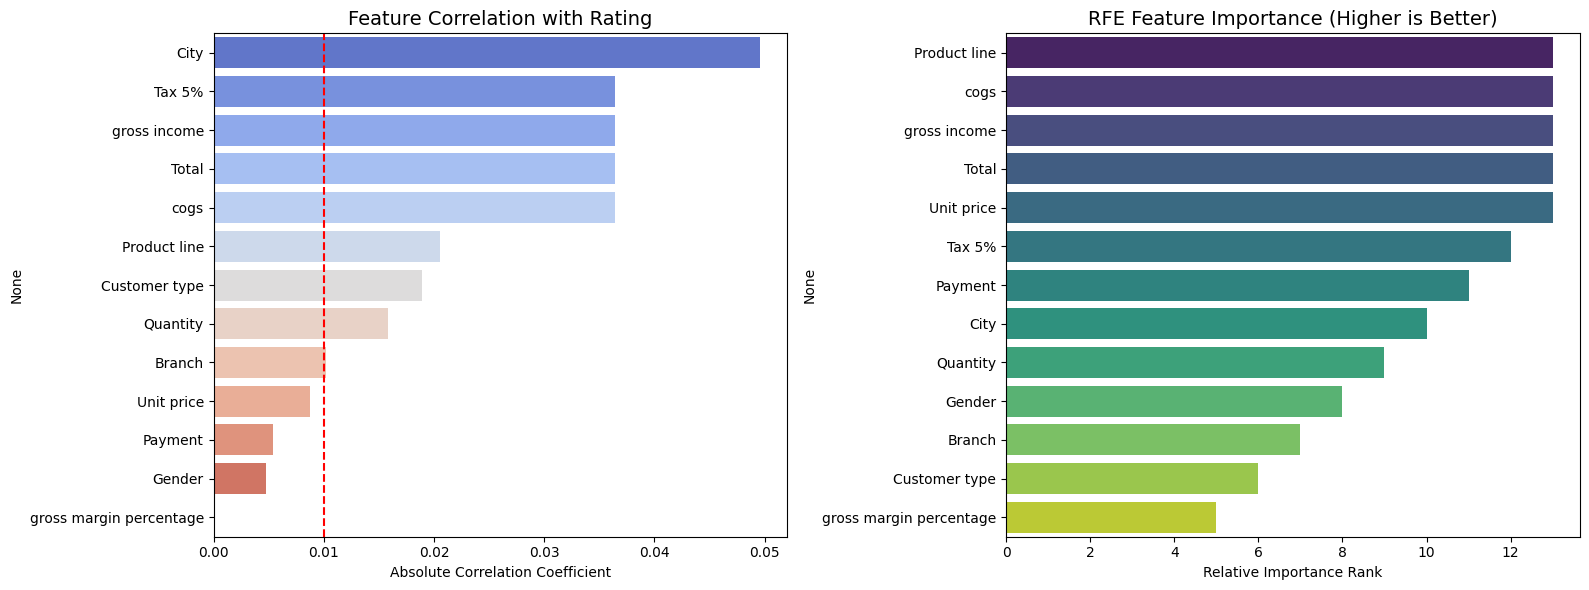

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Correlation Scores
sns.barplot(x=correlations.values, y=correlations.index, ax=axes[0], hue=correlations.index, palette='coolwarm', legend=False)
axes[0].axvline(corr_threshold, color='red', linestyle='--', label=f'Threshold {corr_threshold}')
axes[0].set_title('Feature Correlation with Rating', fontsize=14)
axes[0].set_xlabel('Absolute Correlation Coefficient')

# Plot 2: RFE Rankings
# We invert the ranking for better visualization (higher bar = better feature)
rfe_plot_data = pd.Series(X.shape[1] + 1 - rfe.ranking_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=rfe_plot_data.values, y=rfe_plot_data.index, ax=axes[1], hue=rfe_plot_data.index, palette='viridis', legend=False)
axes[1].set_title('RFE Feature Importance (Higher is Better)', fontsize=14)
axes[1].set_xlabel('Relative Importance Rank')

plt.tight_layout()
plt.show()

3. Next, perform Dimensionality Reduction **(30 Points)**
    - Apply PCA and determine the number of components
    - Then create a visualization

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Scale the data (PCA is sensitive to scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Apply PCA to find components
pca = PCA()
pca.fit(X_scaled)

# 3. Determine number of components for 95% variance
cumsum = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = np.where(cumsum >= 0.95)[0][0] + 1

print(f"Total original features: {X.shape[1]}")
print(f"Number of components to explain 95% variance: {n_components_95}")

# 4. Apply PCA with the determined components
pca_final = PCA(n_components=n_components_95)
X_pca = pca_final.fit_transform(X_scaled)

print(f"Shape of X after PCA: {X_pca.shape}")

Total original features: 13
Number of components to explain 95% variance: 7
Shape of X after PCA: (1000, 7)


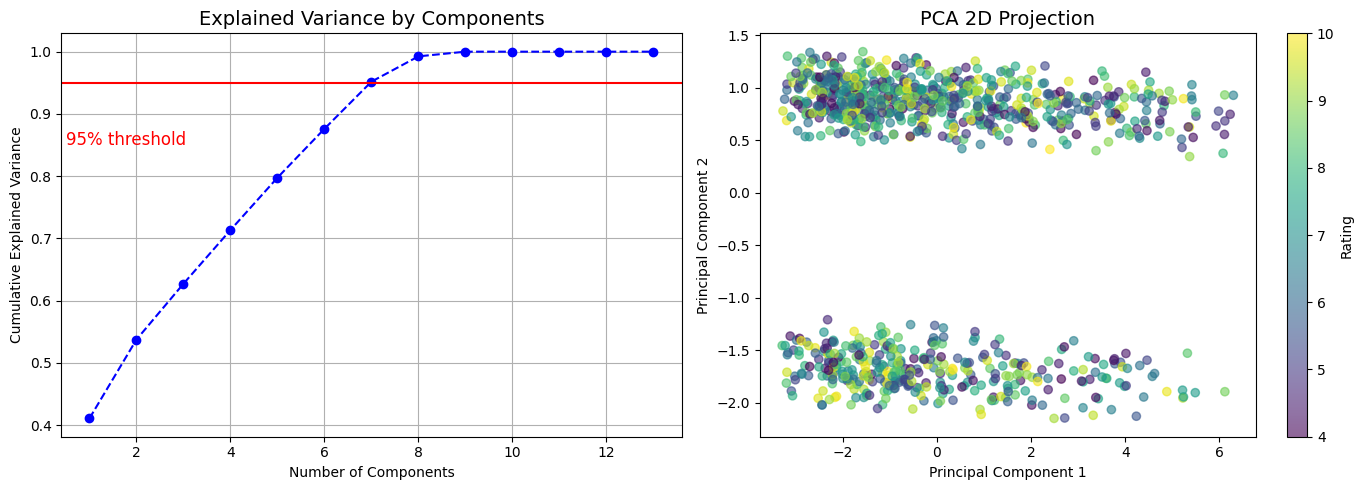

In [ ]:
plt.figure(figsize=(14, 5))

# Plot 1: Cumulative Explained Variance
plt.subplot(1, 2, 1)
plt.plot(range(1, len(cumsum) + 1), cumsum, marker='o', linestyle='--', color='b')
plt.axhline(y=0.95, color='r', linestyle='-')
plt.text(0.5, 0.85, '95% threshold', color = 'red', fontsize=12)
plt.title('Explained Variance by Components', fontsize=14)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)

# Plot 2: 2D PCA Visualization
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

plt.subplot(1, 2, 2)
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='viridis', alpha=0.6)
plt.colorbar(label='Rating')
plt.title('PCA 2D Projection', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.tight_layout()
plt.show()

4. Show the Evaluation Model to the Assistant by showing: **(25 Points)**
    - Comparison of Accuracy between Feature Selection and PCA that you have tried
    - Create a visualization to make it easier to explain to the Assistant

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Prepare datasets
# 1. Baseline (All features)
X_all = X

# 2. RFE Selected Features
X_rfe_sel = X[selected_rfe]

# 3. PCA Components
X_pca_sel = X_pca

def evaluate_model(X_data, y_data):
    X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    return {'MAE': mae, 'R2': r2}

results = {}
results['Baseline (13 Features)'] = evaluate_model(X_all, y)
results['RFE (5 Features)'] = evaluate_model(X_rfe_sel, y)
results['PCA (7 Components)'] = evaluate_model(X_pca_sel, y)

# Create comparison table
results_df = pd.DataFrame(results).T
print("Model Evaluation Comparison:")
print(results_df)

Model Evaluation Comparison:
                             MAE        R2
Baseline (13 Features)  1.582395 -0.139141
RFE (5 Features)        1.538138 -0.141053
PCA (7 Components)      1.569405 -0.110107


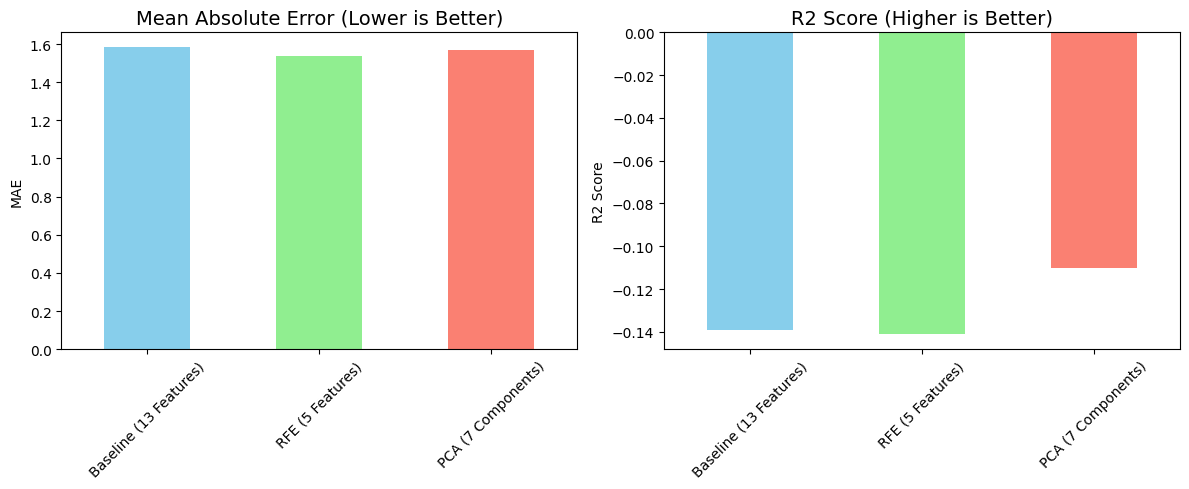

In [ ]:
# Visualization of Model Comparison
plt.figure(figsize=(12, 5))

# Plotting MAE (Lower is better)
plt.subplot(1, 2, 1)
results_df['MAE'].plot(kind='bar', color=['skyblue', 'lightgreen', 'salmon'])
plt.title('Mean Absolute Error (Lower is Better)', fontsize=14)
plt.ylabel('MAE')
plt.xticks(rotation=45)

# Plotting R2 Score (Higher is better)
plt.subplot(1, 2, 2)
results_df['R2'].plot(kind='bar', color=['skyblue', 'lightgreen', 'salmon'])
plt.title('R2 Score (Higher is Better)', fontsize=14)
plt.ylabel('R2 Score')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# **LAB ASSIGNMENTS (80%)**



## **ODD NIM**

**Dataset:** [Customer Churn] Link: [Dataset for ODD NIM](https://drive.google.com/file/d/1dBJtMI27QnkL7GnLG3T5P0m94msbMBst/view?usp=sharing)

---

**Alternative with Kaggle**

```python
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sohailaelsayed/customer-churn")

print("Path to dataset files:", path)

```



**Instructions:**

1. **Feature Selection (25%)**
   - Perform a complete EDA that displays the entire dataset and also provide visualizations. (20 points)
   - Apply two different feature selection methods, namely the Chi-Square Test and Forward Selection. (50 points)
   - Create a comparison visualization and comparison table between the two Feature Selection methods. (30 Points)
2. **Dimensionality Reduction (25%)**
   - Apply PCA: (40 Points)
   - Apply LDA: (40 Points)
   - Compare PCA with LDA using visualizations and comparison tables of the best methods (20 points)

3. **Model Comparison (20%)**
   - Create at least 5 pipelines with: (45 points)
     * Baseline (all features)
     * Best feature selection method
     * PCA
     * LDA
     * Combination (feature selection + PCA)
   - Then evaluate using: (45 Points)
     * Accuracy
     * Precision
     * Recall
     * F1-Score
     * Confusion Matrix
   - Visualize the comparison in tables and graphs (10 Points)

4. **Explain to the Assistant (30%)**


---

### **Lab Assignments - ODD NIM: Customer Churn Prediction**

#### **Dataset Download and Loading**

In [2]:
import kagglehub
import pandas as pd
import os

# Download latest version of the dataset
path = kagglehub.dataset_download("sohailaelsayed/customer-churn")

print("Path to dataset files:", path)

# Assuming the CSV file is directly in the downloaded path or a subdirectory
# List files to find the correct CSV name
files = os.listdir(path)
print("Files in the dataset folder:", files)

# Load the CSV file. Adjust the filename if it's different.
# A common name for this dataset is 'churn.csv' or similar.
csv_file_name = None
for f in files:
    if f.endswith('.csv'):
        csv_file_name = f
        break

if csv_file_name:
    df_churn = pd.read_csv(os.path.join(path, csv_file_name))
    print(f"\nDataset '{csv_file_name}' loaded successfully.")
    print("\nFirst 5 rows of the dataset:")
    display(df_churn.head())
    print("\nDataset Info:")
    df_churn.info()
else:
    print("No CSV file found in the dataset folder.")

Using Colab cache for faster access to the 'customer-churn' dataset.
Path to dataset files: /kaggle/input/customer-churn
Files in the dataset folder: ['customer_churn_dataset-testing-master.csv', 'customer_churn_dataset-training-master.csv']

Dataset 'customer_churn_dataset-testing-master.csv' loaded successfully.

First 5 rows of the dataset:


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


#### **1. Exploratory Data Analysis (EDA)**

**Display descriptive statistics and check for missing values.**

In [3]:
# Display descriptive statistics
print("\nDescriptive Statistics:")
display(df_churn.describe(include='all'))

# Check for missing values
print("\nMissing Values:")
print(df_churn.isnull().sum())


Descriptive Statistics:


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374,64374.000000,64374.000000,64374.000000,64374.000000,64374,64374,64374.000000,64374.000000,64374.000000
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,NaN,NaN,NaN
top,NaN,NaN,Female,NaN,NaN,NaN,NaN,Standard,Monthly,NaN,NaN,NaN
freq,NaN,NaN,34353,NaN,NaN,NaN,NaN,21502,22130,NaN,NaN,NaN
mean,32187.500000,41.970982,NaN,31.994827,15.080234,5.400690,17.133952,NaN,NaN,541.023379,15.498850,0.473685
std,18583.317451,13.924911,NaN,17.098234,8.816470,3.114005,8.852211,NaN,NaN,260.874809,8.638436,0.499311
min,1.000000,18.000000,NaN,1.000000,1.000000,0.000000,0.000000,NaN,NaN,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,NaN,18.000000,7.000000,3.000000,10.000000,NaN,NaN,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,NaN,33.000000,15.000000,6.000000,19.000000,NaN,NaN,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,NaN,47.000000,23.000000,8.000000,25.000000,NaN,NaN,768.000000,23.000000,1.000000



Missing Values:
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64


#### **1.1 Complete EDA with Visualizations**


Entire dataset (first 10 rows and last 10 rows for overview):


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0
5,6,30,Male,41,14,10,10,Premium,Monthly,500,29,0
6,7,47,Female,37,15,9,28,Basic,Quarterly,574,14,1
7,8,54,Female,36,11,0,18,Standard,Monthly,323,16,0
8,9,36,Male,20,5,10,8,Basic,Monthly,687,8,0
9,10,65,Male,8,4,2,23,Basic,Annual,995,10,0



Dataset shape: (64374, 12)


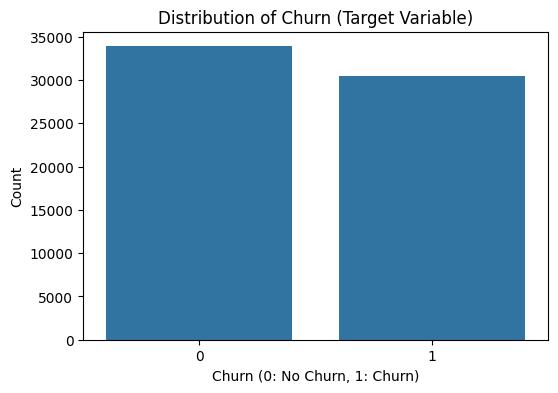

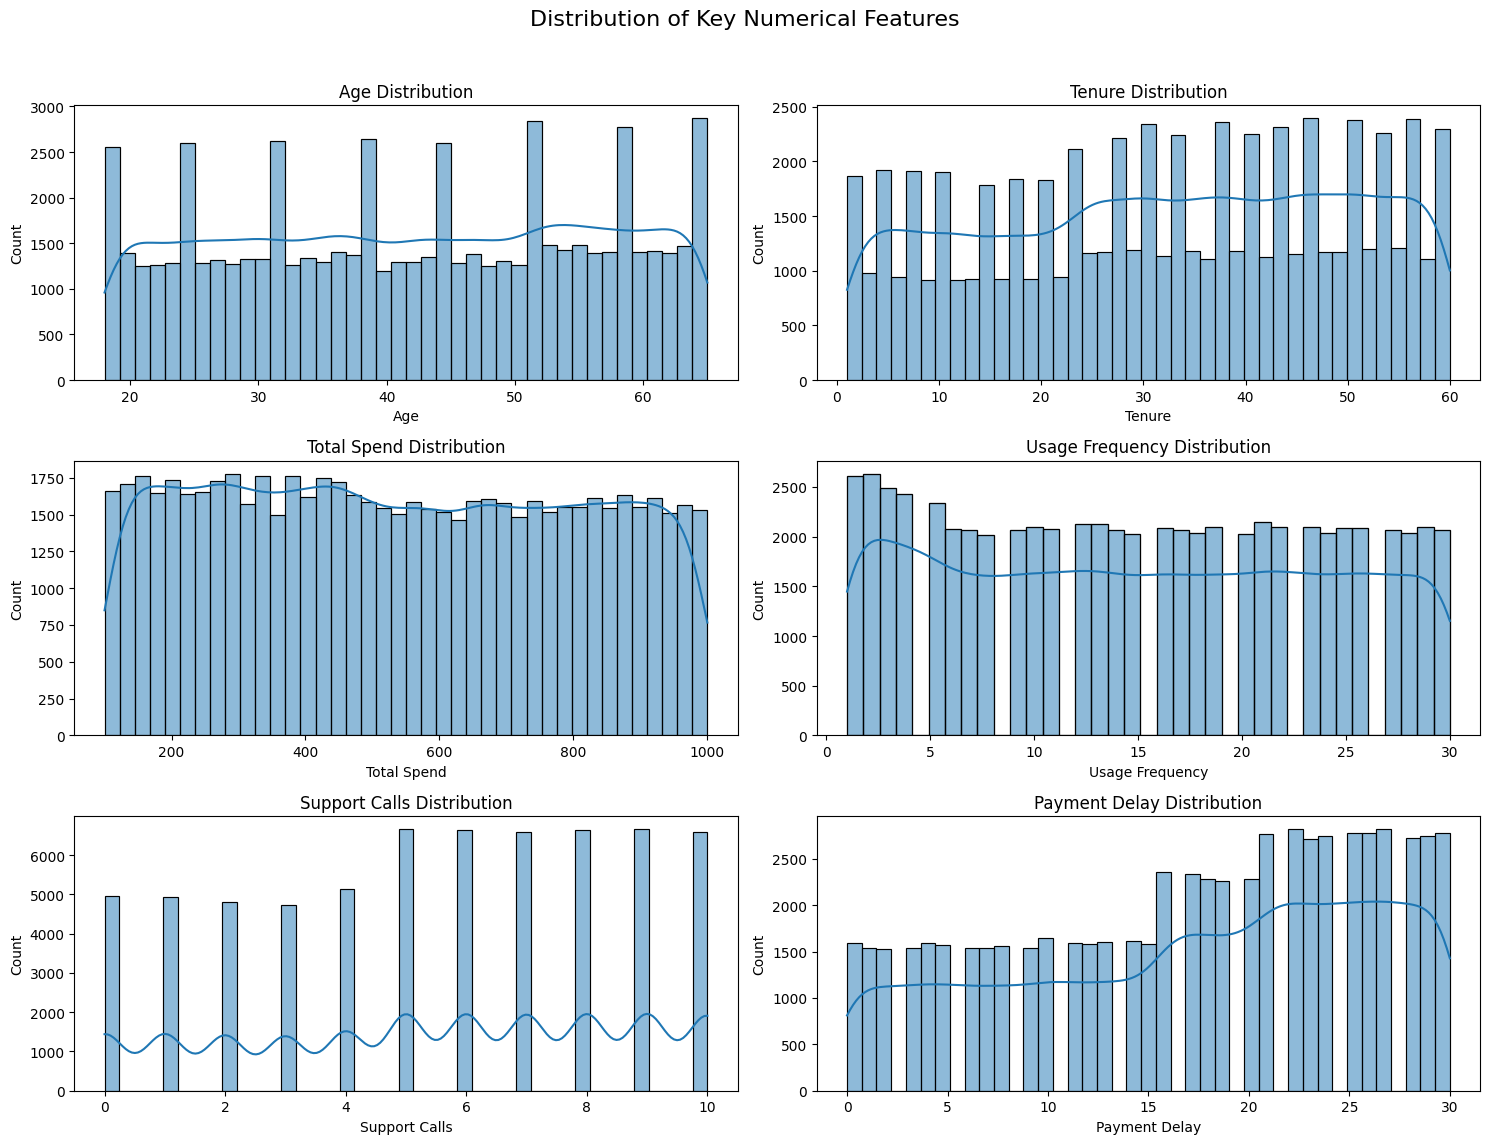

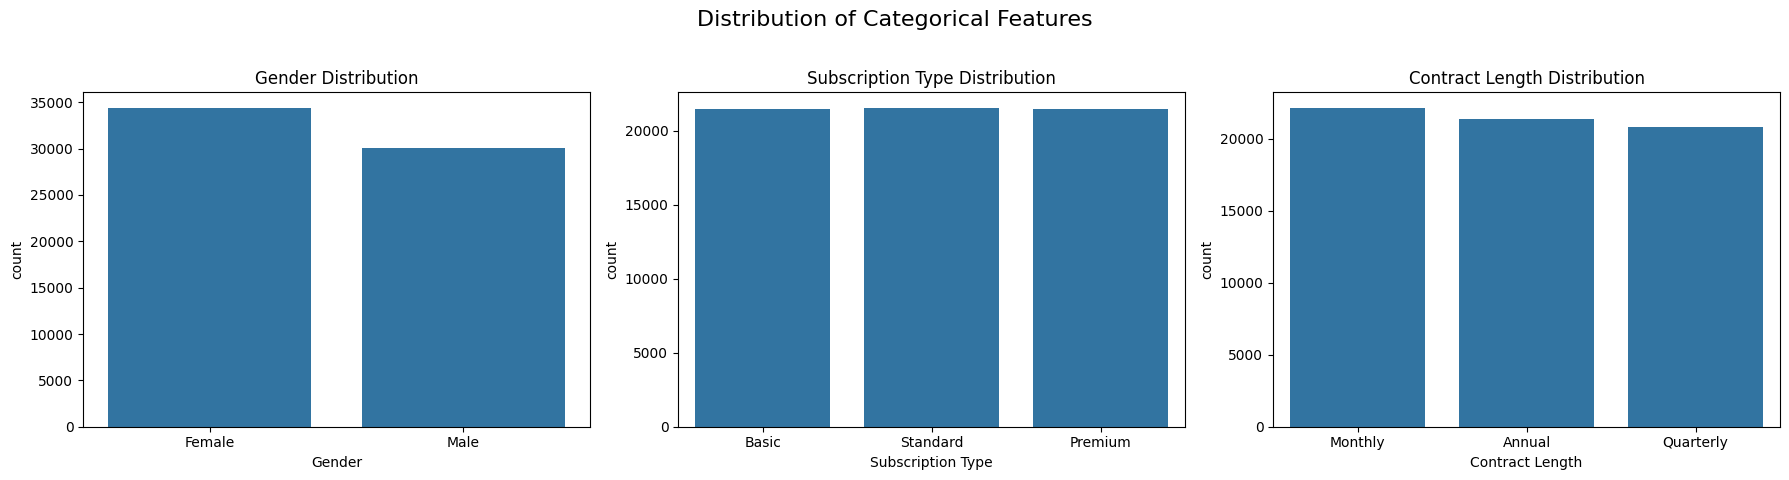


Correlation Heatmap of Numerical Features:


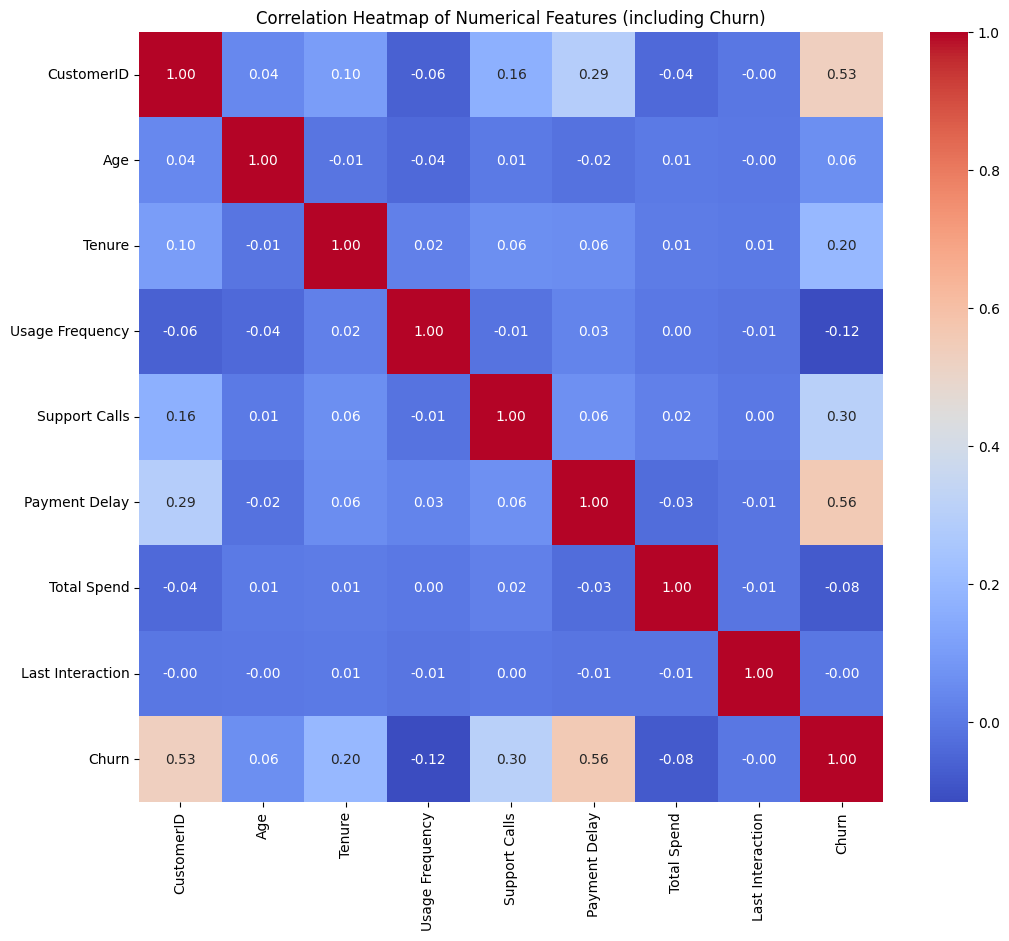

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Display the entire dataset (or a large sample if it's too big to display fully)
print("\nEntire dataset (first 10 rows and last 10 rows for overview):")
display(pd.concat([df_churn.head(10), df_churn.tail(10)]))

print("\nDataset shape:", df_churn.shape)

# Visualize the distribution of the target variable (Churn)
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df_churn)
plt.title('Distribution of Churn (Target Variable)')
plt.xlabel('Churn (0: No Churn, 1: Churn)')
plt.ylabel('Count')
plt.show()

# Visualize distributions of key numerical features
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 12))
fig.suptitle('Distribution of Key Numerical Features', fontsize=16)

sns.histplot(df_churn['Age'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Age Distribution')

sns.histplot(df_churn['Tenure'], kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Tenure Distribution')

sns.histplot(df_churn['Total Spend'], kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Total Spend Distribution')

sns.histplot(df_churn['Usage Frequency'], kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Usage Frequency Distribution')

sns.histplot(df_churn['Support Calls'], kde=True, ax=axes[2, 0])
axes[2, 0].set_title('Support Calls Distribution')

sns.histplot(df_churn['Payment Delay'], kde=True, ax=axes[2, 1])
axes[2, 1].set_title('Payment Delay Distribution')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()


# Visualize distributions of categorical features
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
fig.suptitle('Distribution of Categorical Features', fontsize=16)

sns.countplot(x='Gender', data=df_churn, ax=axes[0])
axes[0].set_title('Gender Distribution')

sns.countplot(x='Subscription Type', data=df_churn, ax=axes[1])
axes[1].set_title('Subscription Type Distribution')

sns.countplot(x='Contract Length', data=df_churn, ax=axes[2])
axes[2].set_title('Contract Length Distribution')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

# Create a correlation heatmap for numerical features
print("\nCorrelation Heatmap of Numerical Features:")
plt.figure(figsize=(12, 10))
sns.heatmap(df_churn.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features (including Churn)')
plt.show()


#### **2. Feature Selection**

#### **2.1 Preprocessing for Feature Selection**

In [5]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Create a copy to avoid altering the original dataframe
df_fs = df_churn.copy()

# Define target and features
target_column = 'Churn'
X_fs = df_fs.drop(columns=[target_column, 'CustomerID']) # Drop CustomerID as it's an identifier
y_fs = df_fs[target_column]

# Identify categorical and numerical features
categorical_cols_fs = X_fs.select_dtypes(include=['object']).columns.tolist()
numerical_cols_fs = X_fs.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical features for Feature Selection:", categorical_cols_fs)
print("Numerical features for Feature Selection:", numerical_cols_fs)

# Encode categorical features
le = LabelEncoder()
for col in categorical_cols_fs:
    X_fs[col] = le.fit_transform(X_fs[col])

print("\nFeatures after encoding categorical variables (first 5 rows):")
display(X_fs.head())

# Split data into training and testing sets (needed for Forward Selection later)
X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(X_fs, y_fs, test_size=0.3, random_state=42, stratify=y_fs)

print(f"\nShape of X_train_fs: {X_train_fs.shape}")
print(f"Shape of X_test_fs: {X_test_fs.shape}")

Categorical features for Feature Selection: ['Gender', 'Subscription Type', 'Contract Length']
Numerical features for Feature Selection: ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction']

Features after encoding categorical variables (first 5 rows):


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
0,22,0,25,14,4,27,0,1,598,9
1,41,0,28,28,7,13,2,1,584,20
2,47,1,27,10,2,29,1,0,757,21
3,35,1,9,12,5,17,1,2,232,18
4,53,0,58,24,9,2,2,0,533,18



Shape of X_train_fs: (45061, 10)
Shape of X_test_fs: (19313, 10)


#### **2.2 Apply Chi-Square Test**

In [6]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler

# Chi-Square requires non-negative features. Min-Max Scale the data.
scaler_chi2 = MinMaxScaler()
X_scaled_chi2 = scaler_chi2.fit_transform(X_fs)

# Apply Chi-Square test to select features (e.g., top 7 features)
k_features_chi2 = min(7, X_fs.shape[1]) # Select top 7 or fewer if less are available
chi2_selector = SelectKBest(chi2, k=k_features_chi2)
chi2_selector.fit(X_scaled_chi2, y_fs)

# Get selected features and their scores
selected_features_chi2_idx = chi2_selector.get_support(indices=True)
selected_features_chi2_names = X_fs.columns[selected_features_chi2_idx].tolist()

chi2_scores = pd.DataFrame({
    'Feature': X_fs.columns,
    'Chi2_Score': chi2_selector.scores_
}).sort_values('Chi2_Score', ascending=False)

print("\nChi-Square Scores:")
display(chi2_scores)

print(f"\nFeatures selected with Chi-Square Test (top {k_features_chi2}):")
print(selected_features_chi2_names)


Chi-Square Scores:


,Feature,Chi2_Score
5,Payment Delay,3048.878733
4,Support Calls,1072.609485
1,Gender,930.150186
2,Tenure,392.636427
3,Usage Frequency,162.339114
8,Total Spend,68.652875
0,Age,44.613213
7,Contract Length,6.229523
6,Subscription Type,1.284836
9,Last Interaction,0.090726



Features selected with Chi-Square Test (top 7):
['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend']


#### **2.3 Apply Forward Selection**

In [7]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression

# Using Logistic Regression as the estimator for Forward Selection
estimator_fs = LogisticRegression(max_iter=1000, random_state=42)

# Apply Forward Selection to select features (e.g., top 7 features)
k_features_fs = min(7, X_fs.shape[1]) # Select top 7 or fewer if less are available
forward_selector = SequentialFeatureSelector(
    estimator_fs,
    n_features_to_select=k_features_fs,
    direction='forward',
    cv=5, # Using 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1 # Use all available cores
)

# Fit on the training data
forward_selector.fit(X_train_fs, y_train_fs)

# Get selected features
selected_features_forward_names = X_fs.columns[forward_selector.get_support()].tolist()

print(f"Features selected with Forward Selection (top {k_features_fs}):")
print(selected_features_forward_names)

Features selected with Forward Selection (top 7):
['Gender', 'Tenure', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Total Spend', 'Last Interaction']


#### **2.4 Comparison of Feature Selection Methods**


Comparison Table of Selected Features:


,Chi-Square Selected Features,Forward Selection Selected Features
0,Age,Gender
1,Gender,Tenure
2,Tenure,Support Calls
3,Usage Frequency,Payment Delay
4,Support Calls,Subscription Type
5,Payment Delay,Total Spend
6,Total Spend,Last Interaction


/tmp/ipykernel_803/458866293.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Chi2_Score', y='Feature', data=chi2_scores.head(k_features_chi2), palette='viridis')


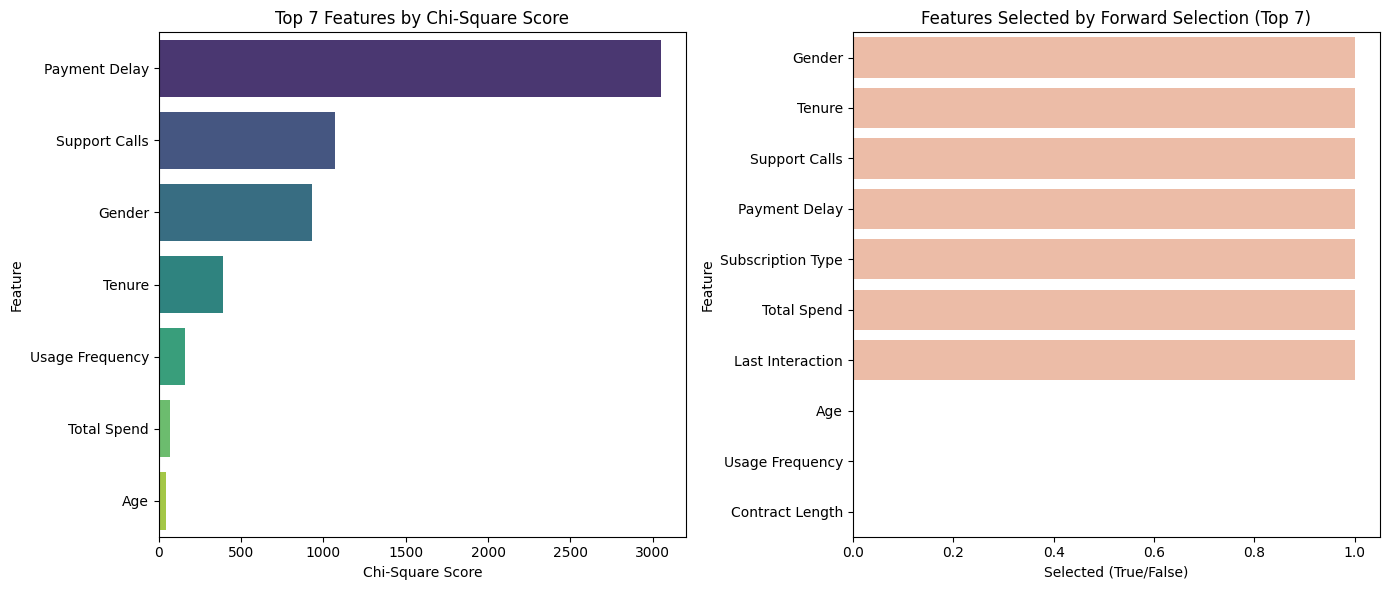

In [8]:
# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Chi-Square Selected Features': pd.Series(selected_features_chi2_names),
    'Forward Selection Selected Features': pd.Series(selected_features_forward_names)
})

print("\nComparison Table of Selected Features:")
display(comparison_df)

# Visualize comparison (e.g., using Venn diagram or bar plots if feature sets are very different)
# For simplicity, let's visualize the scores/rankings for direct comparison

# For Chi-Square, we have scores
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.barplot(x='Chi2_Score', y='Feature', data=chi2_scores.head(k_features_chi2), palette='viridis')
plt.title(f'Top {k_features_chi2} Features by Chi-Square Score')
plt.xlabel('Chi-Square Score')
plt.ylabel('Feature')

# For Forward Selection, we don't have direct 'scores' but we have the selected features.
# We can show their presence in the selected set.
fs_presence = pd.DataFrame({
    'Feature': X_fs.columns,
    'Selected': X_fs.columns.isin(selected_features_forward_names)
}).sort_values('Selected', ascending=False)

plt.subplot(1, 2, 2)
sns.barplot(x='Selected', y='Feature', data=fs_presence, palette='coolwarm', hue='Selected', legend=False)
plt.title(f'Features Selected by Forward Selection (Top {k_features_fs})')
plt.xlabel('Selected (True/False)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

#### **4. Model Comparison**

--- Baseline (All Features) Results ---
Accuracy: 0.9990
Precision: 0.9996
Recall: 0.9984
F1-Score: 0.9990
Confusion Matrix:
[[10161     4]
 [   15  9133]]
------------------------------
--- Forward Selection Features Results ---
Accuracy: 0.9170
Precision: 0.9553
Recall: 0.8652
F1-Score: 0.9080
Confusion Matrix:
[[9795  370]
 [1233 7915]]
------------------------------
--- PCA Components Results ---
Accuracy: 0.9235
Precision: 0.9138
Recall: 0.9259
F1-Score: 0.9198
Confusion Matrix:
[[9366  799]
 [ 678 8470]]
------------------------------
--- LDA Components Results ---
Accuracy: 0.7548
Precision: 0.7394
Recall: 0.7448
F1-Score: 0.7421
Confusion Matrix:
[[7764 2401]
 [2335 6813]]
------------------------------
--- Forward Selection + PCA Combo Results ---
Accuracy: 0.9000
Precision: 0.9247
Recall: 0.8588
F1-Score: 0.8905
Confusion Matrix:
[[9525  640]
 [1292 7856]]
------------------------------

--- Model Performance Comparison ---


,Accuracy,Precision,Recall,F1-Score
Name,,,,
Baseline (All Features),0.999016,0.999562,0.998360,0.998961
Forward Selection Features,0.916999,0.955341,0.865216,0.908048
PCA Components,0.923523,0.913799,0.925885,0.919802
LDA Components,0.754777,0.739418,0.744753,0.742076
Forward Selection + PCA Combo,0.899964,0.924670,0.858767,0.890501


/tmp/ipykernel_803/1986558552.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics_df.index, y='Accuracy', data=metrics_df, palette='viridis')
/tmp/ipykernel_803/1986558552.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics_df.index, y='Precision', data=metrics_df, palette='magma')
/tmp/ipykernel_803/1986558552.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics_df.index, y='Recall', data=metrics_df, palette='cividis')
/tmp/ipykernel_803/1986558552.py:116: FutureWarning: 

Passing `palette` without assignin

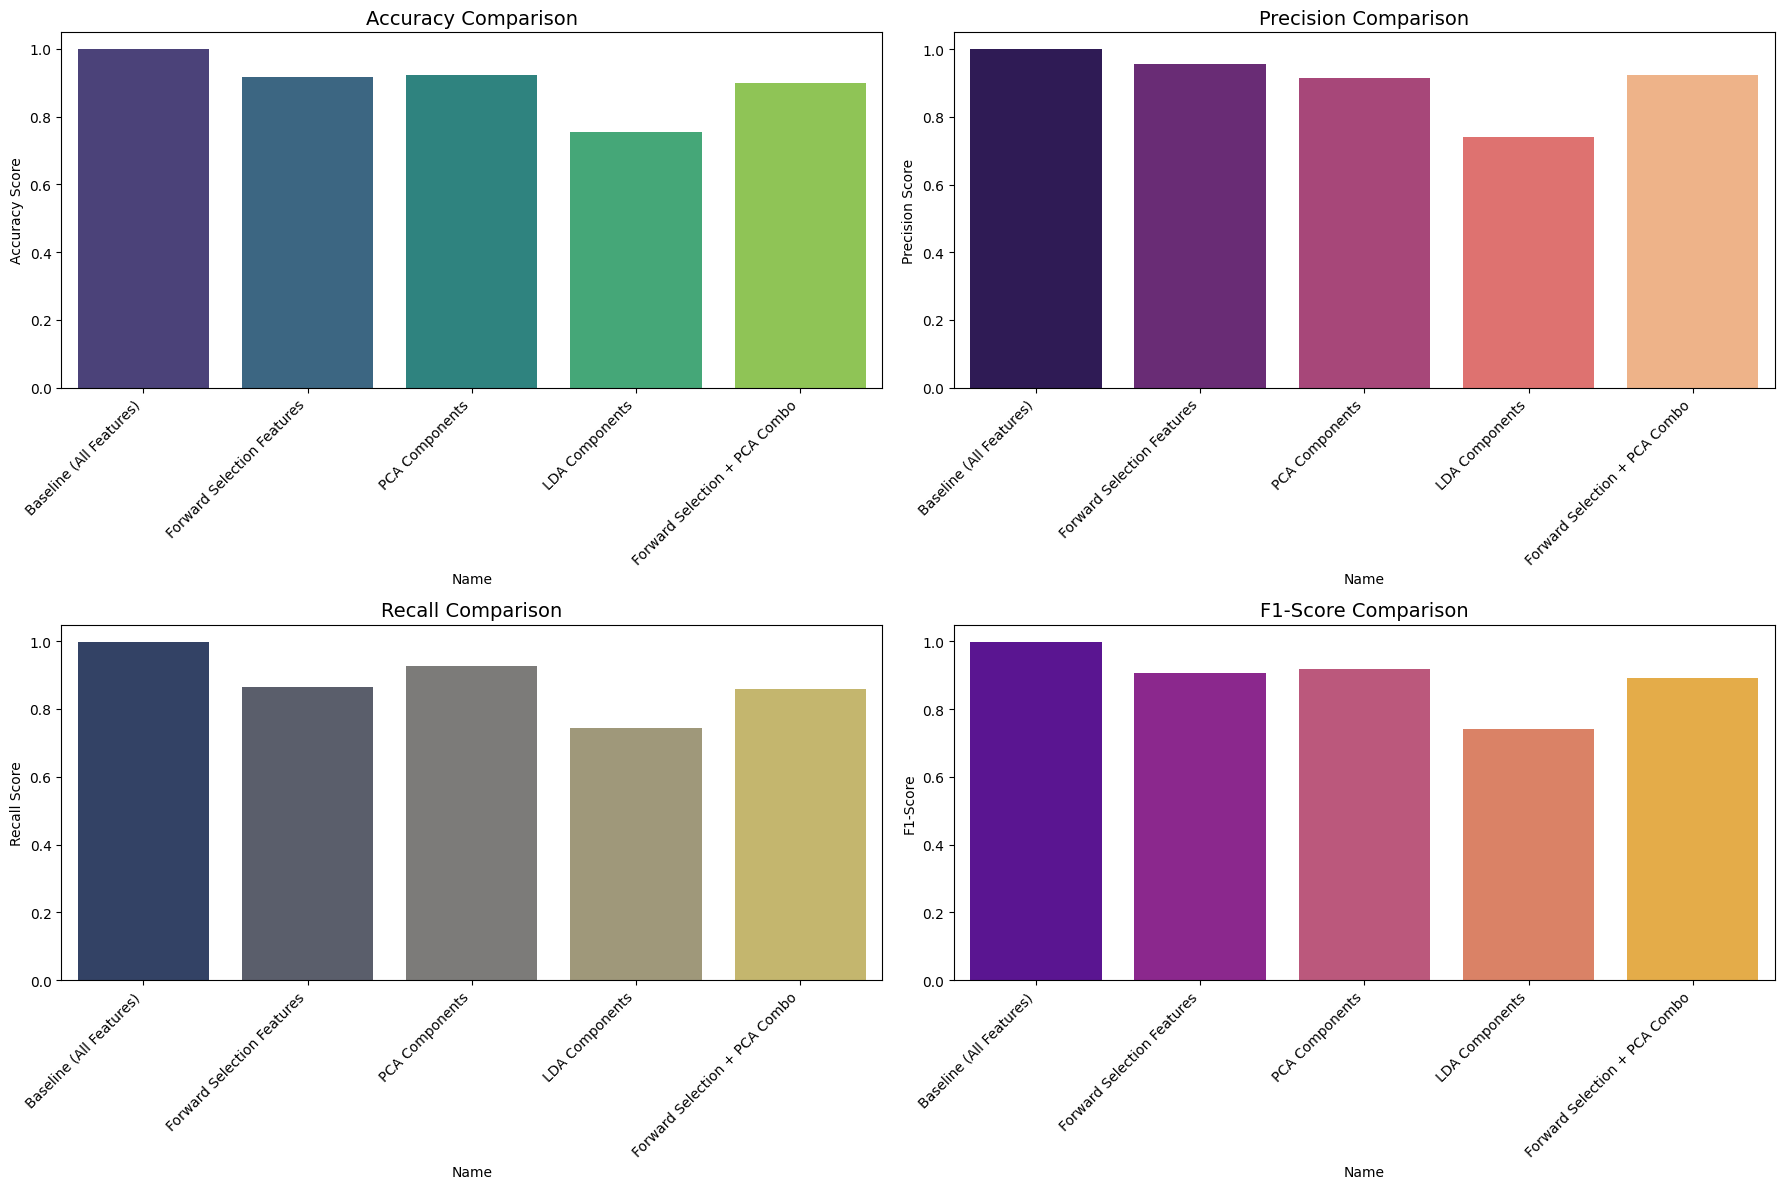

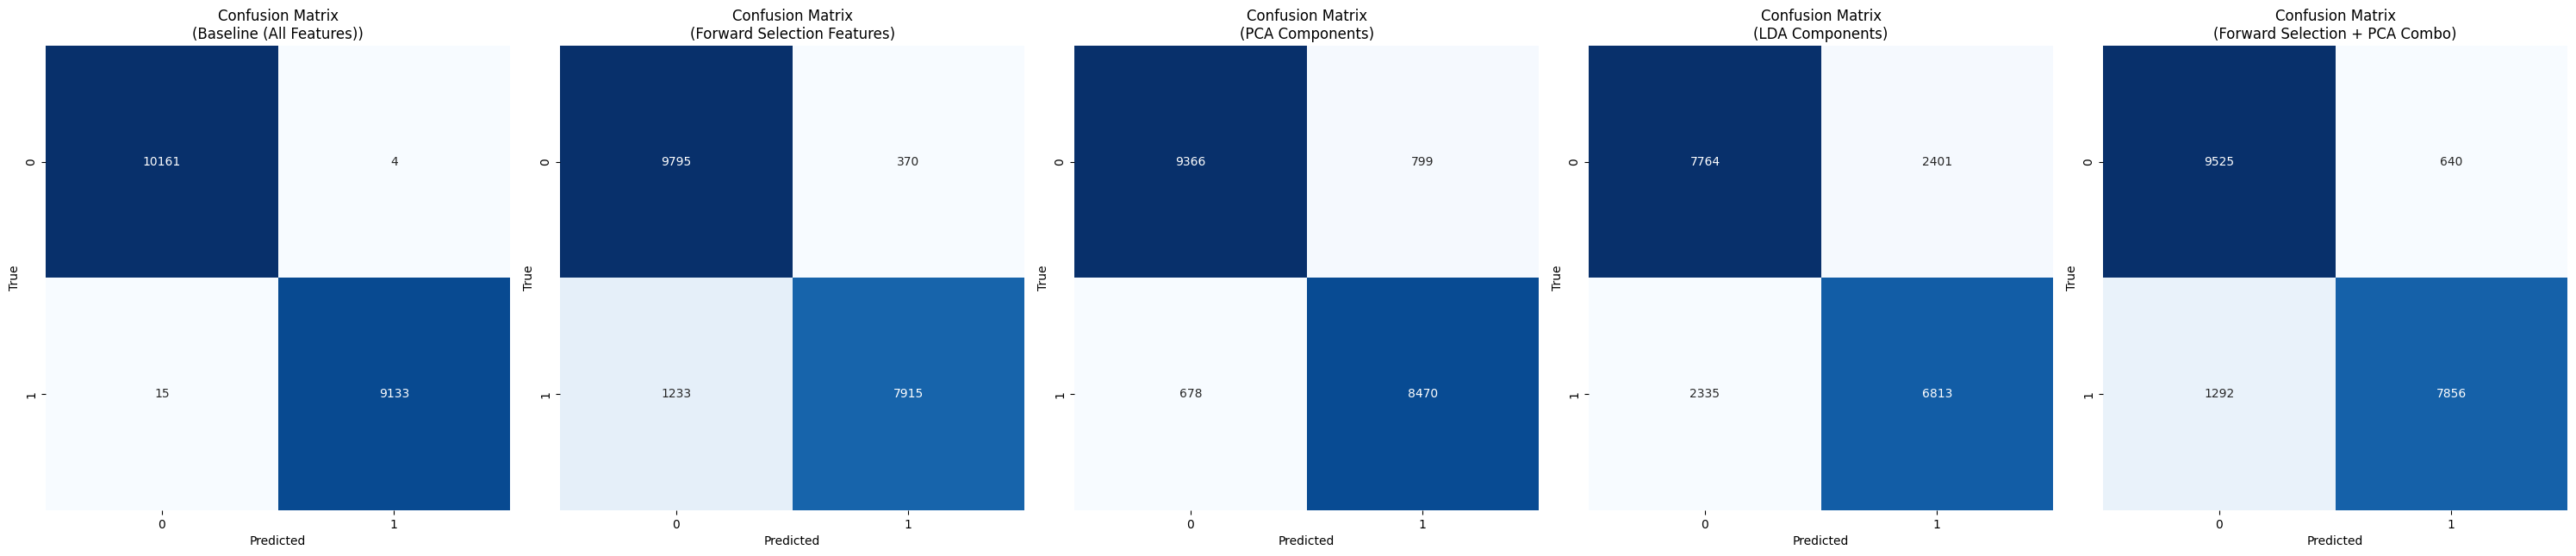

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# --- Define an evaluation function for pipelines ---

def evaluate_pipeline(name, X_data, y_data):
    # Split data into training and testing sets (70/30 split)
    X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.3, random_state=42, stratify=y_data)

    # Initialize and train a RandomForestClassifier
    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"--- {name} Results ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print("-" * 30)

    return {'Name': name, 'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1-Score': f1, 'Confusion Matrix': cm}

# --- Prepare data for each pipeline ---

# 1. Baseline (all features)
# Ensure X_fs is scaled for consistency before passing to evaluate_pipeline
scaler_baseline = StandardScaler()
X_baseline_scaled = scaler_baseline.fit_transform(X_fs)
X_baseline_df = pd.DataFrame(X_baseline_scaled, columns=X_fs.columns)

# 2. Best feature selection method (Forward Selection features)
X_fs_selected = X_fs[selected_features_forward_names]
scaler_fs_selected = StandardScaler()
X_fs_selected_scaled = scaler_fs_selected.fit_transform(X_fs_selected)
X_fs_selected_df = pd.DataFrame(X_fs_selected_scaled, columns=selected_features_forward_names)

# 3. PCA Components
# X_pca_transformed should be available from the previous PCA cell
X_pca_df = pd.DataFrame(X_pca_transformed, columns=[f'PC{i+1}' for i in range(X_pca_transformed.shape[1])])

# 4. LDA Components
# X_lda_transformed should be available from the previous LDA cell
X_lda_df = pd.DataFrame(X_lda_transformed, columns=[f'LD{i+1}' for i in range(X_lda_transformed.shape[1])])

# 5. Combination (Feature Selection + PCA)
# First, select features using Forward Selection, then apply PCA
X_combo_fs = X_fs[selected_features_forward_names]
scaler_combo_fs = StandardScaler()
X_combo_fs_scaled = scaler_combo_fs.fit_transform(X_combo_fs)

# Use the same number of components as in the main PCA if possible, or adjust dynamically
pca_combo = PCA(n_components=min(n_components_95_pca, X_combo_fs_scaled.shape[1]))
X_combo_pca_transformed = pca_combo.fit_transform(X_combo_fs_scaled)
X_combo_df = pd.DataFrame(X_combo_pca_transformed, columns=[f'Combo_PC{i+1}' for i in range(X_combo_pca_transformed.shape[1])])

# --- Run evaluation for each pipeline ---
all_results = []
all_results.append(evaluate_pipeline('Baseline (All Features)', X_baseline_df, y_fs))
all_results.append(evaluate_pipeline('Forward Selection Features', X_fs_selected_df, y_fs))
all_results.append(evaluate_pipeline('PCA Components', X_pca_df, y_fs))
all_results.append(evaluate_pipeline('LDA Components', X_lda_df, y_fs))
all_results.append(evaluate_pipeline('Forward Selection + PCA Combo', X_combo_df, y_fs))

# --- Create comparison table ---
metrics_df = pd.DataFrame([
    {k: v for k, v in res.items() if k != 'Confusion Matrix'} for res in all_results
]).set_index('Name')

print("\n--- Model Performance Comparison ---")
display(metrics_df)

# --- Visualize the comparison ---
plt.figure(figsize=(18, 12))

# Accuracy
plt.subplot(2, 2, 1)
sns.barplot(x=metrics_df.index, y='Accuracy', data=metrics_df, palette='viridis')
plt.title('Accuracy Comparison', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Accuracy Score')

# Precision
plt.subplot(2, 2, 2)
sns.barplot(x=metrics_df.index, y='Precision', data=metrics_df, palette='magma')
plt.title('Precision Comparison', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Precision Score')

# Recall
plt.subplot(2, 2, 3)
sns.barplot(x=metrics_df.index, y='Recall', data=metrics_df, palette='cividis')
plt.title('Recall Comparison', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Recall Score')

# F1-Score
plt.subplot(2, 2, 4)
sns.barplot(x=metrics_df.index, y='F1-Score', data=metrics_df, palette='plasma')
plt.title('F1-Score Comparison', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylabel('F1-Score')

plt.tight_layout()
plt.show()

# --- Confusion Matrix Visualization (for each model) ---
fig, axes = plt.subplots(1, len(all_results), figsize=(len(all_results) * 6, 6))
if len(all_results) == 1: # Handle case of single subplot
    axes = [axes]

for i, res in enumerate(all_results):
    sns.heatmap(res['Confusion Matrix'], annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'Confusion Matrix\n({res["Name"]})')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')
    axes[i].set_aspect('equal', adjustable='box') # Ensure squares are square

plt.tight_layout()
plt.show()


#### **5. Explanation to the Assistant**

#### **3. Dimensionality Reduction**

#### **3.1 Apply PCA**

Total original features for PCA: 10
Number of components required to explain 95% variance: 10
Shape of X after PCA: (64374, 10)

Explained variance ratio by each component:
[0.11278593 0.10858897 0.10337846 0.1005388  0.10032516 0.10015609
 0.09681207 0.09624502 0.09292651 0.08824298]


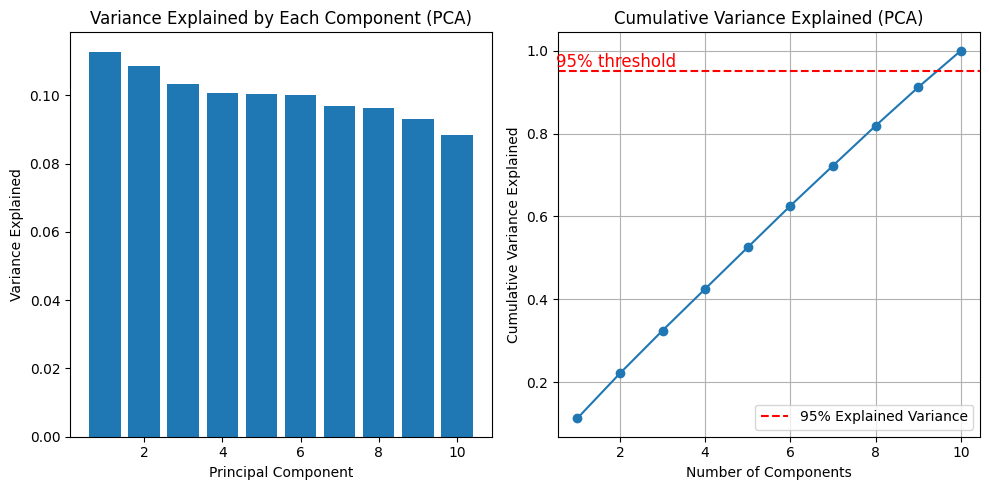

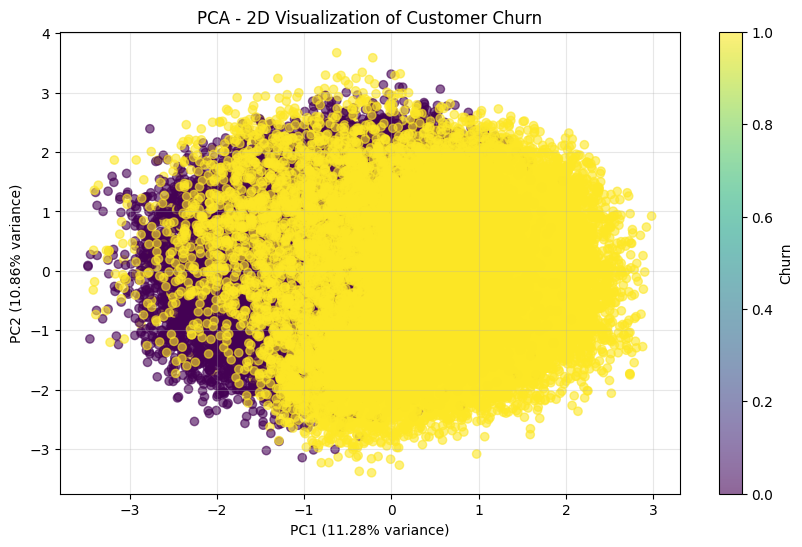

In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scale the data before applying PCA
scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(X_fs)

# Apply PCA
pca = PCA()
pca.fit(X_scaled_pca)

# Determine number of components for 95% variance
cumsum_variance_pca = np.cumsum(pca.explained_variance_ratio_)
n_components_95_pca = np.where(cumsum_variance_pca >= 0.95)[0][0] + 1

print(f"Total original features for PCA: {X_fs.shape[1]}")
print(f"Number of components required to explain 95% variance: {n_components_95_pca}")

# Apply PCA with optimal components for transformation
pca_final = PCA(n_components=n_components_95_pca)
X_pca_transformed = pca_final.fit_transform(X_scaled_pca)

print(f"Shape of X after PCA: {X_pca_transformed.shape}")
print("\nExplained variance ratio by each component:")
print(pca_final.explained_variance_ratio_)

# Visualization of explained variance
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('Variance Explained by Each Component (PCA)')

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumsum_variance_pca) + 1), cumsum_variance_pca, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Explained Variance')
plt.text(0.5, 0.96, '95% threshold', color = 'red', fontsize=12)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.title('Cumulative Variance Explained (PCA)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# 2D Visualization of PCA components
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled_pca)

plt.figure(figsize=(10, 6))
scatter_pca = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y_fs, cmap='viridis', alpha=0.6)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} variance)')
plt.title('PCA - 2D Visualization of Customer Churn')
plt.colorbar(scatter_pca, label='Churn')
plt.grid(True, alpha=0.3)
plt.show()


#### **3.2 Apply LDA**

Number of classes for LDA: 2
Maximum possible LDA components: 1
Shape of X after LDA: (64374, 1)

Explained variance ratio by each Linear Discriminant:
[1.]


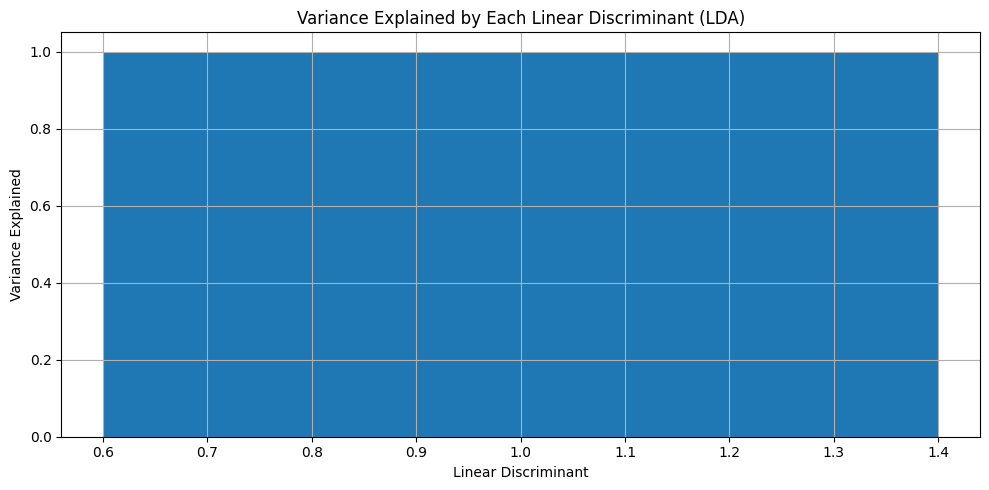

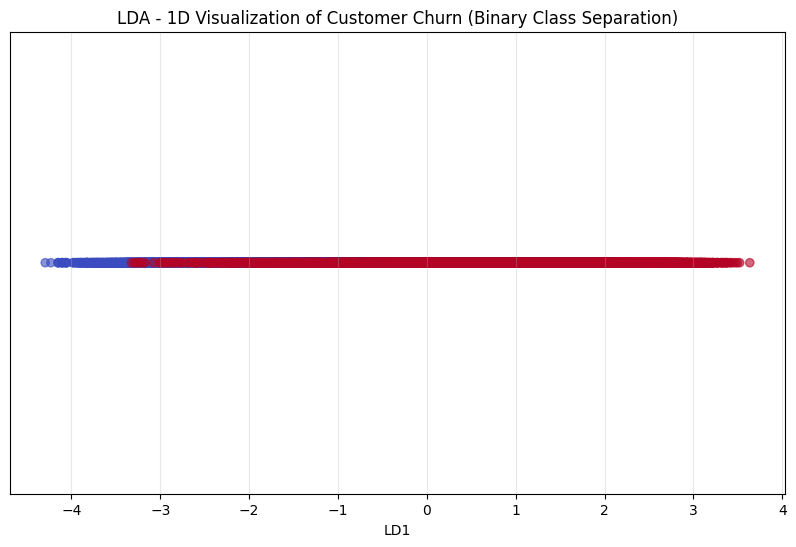

In [10]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Note: LDA's n_components is limited to (n_classes - 1) or n_features, whichever is smaller.
n_classes_lda = len(np.unique(y_fs)) # Number of unique classes in the target variable
n_features_lda = X_fs.shape[1] # Number of features
max_lda_components = min(n_features_lda, n_classes_lda - 1)

if max_lda_components < 1:
    print("[WARNING] LDA cannot be applied. Target variable has less than 2 classes.")
else:
    print(f"Number of classes for LDA: {n_classes_lda}")
    print(f"Maximum possible LDA components: {max_lda_components}")

    # Scale the data (important for LDA)
    scaler_lda = StandardScaler()
    X_scaled_lda = scaler_lda.fit_transform(X_fs)

    # Apply LDA
    lda = LinearDiscriminantAnalysis(n_components=max_lda_components)
    X_lda_transformed = lda.fit_transform(X_scaled_lda, y_fs)

    print(f"Shape of X after LDA: {X_lda_transformed.shape}")

    if max_lda_components > 0:
        print("\nExplained variance ratio by each Linear Discriminant:")
        print(lda.explained_variance_ratio_)

        # Visualization of explained variance (Discriminability)
        plt.figure(figsize=(10, 5))
        plt.bar(range(1, max_lda_components + 1), lda.explained_variance_ratio_)
        plt.xlabel('Linear Discriminant')
        plt.ylabel('Variance Explained')
        plt.title('Variance Explained by Each Linear Discriminant (LDA)')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # 2D Visualization of LDA components (if possible, otherwise 1D)
        plt.figure(figsize=(10, 6))
        if max_lda_components >= 2:
            scatter_lda = plt.scatter(X_lda_transformed[:, 0], X_lda_transformed[:, 1], c=y_fs, cmap='coolwarm', alpha=0.6)
            plt.xlabel('LD1')
            plt.ylabel('LD2')
            plt.title('LDA - 2D Visualization of Customer Churn (Max Class Separability)')
            plt.colorbar(scatter_lda, label='Churn')
        else: # For binary classification, only 1 component is generated
            plt.scatter(X_lda_transformed[:, 0], np.zeros_like(X_lda_transformed[:, 0]), c=y_fs, cmap='coolwarm', alpha=0.6)
            plt.xlabel('LD1')
            plt.title('LDA - 1D Visualization of Customer Churn (Binary Class Separation)')
            plt.yticks([]) # Remove the Y-axis
        plt.grid(True, alpha=0.3)
        plt.show()


#### **3.3 Comparison of PCA and LDA**

In [11]:
import pandas as pd

# Create a DataFrame to summarize the key characteristics of PCA and LDA
comparison_dr_df = pd.DataFrame({
    'Aspect': ['Type', 'Linear/Non-linear', 'Primary Goal', 'Output', 'Target Consideration'],
    'PCA': ['Unsupervised', 'Linear', 'Maximize variance', 'Principal Components', 'Ignores Target'],
    'LDA': ['Supervised', 'Linear', 'Maximize class separation', 'Linear Discriminants', 'Uses Target']
})

print("\nComparison Table of PCA vs. LDA:")
display(comparison_dr_df)

print("\nKey observations from PCA and LDA for Customer Churn dataset:")
print(f"- PCA reduced {X_fs.shape[1]} features to {n_components_95_pca} components to retain 95% variance.")
print(f"- LDA reduced {X_fs.shape[1]} features to {max_lda_components} components (since there are {n_classes_lda} target classes).")
print("\nVisualizations for both methods show how data is projected into lower dimensions.")
print("PCA aims to capture the most data variability, while LDA aims to find projections that best separate the 'Churn' classes.")

# Discussion based on visualizations (assuming previous cells ran and generated plots)
print("\nFrom the 2D visualizations:")
print("- PCA visualization tends to show the overall data structure.")
print("- LDA visualization aims to show clearer separation between churn and non-churn groups, if such linear separation exists.")



Comparison Table of PCA vs. LDA:


,Aspect,PCA,LDA
0,Type,Unsupervised,Supervised
1,Linear/Non-linear,Linear,Linear
2,Primary Goal,Maximize variance,Maximize class separation
3,Output,Principal Components,Linear Discriminants
4,Target Consideration,Ignores Target,Uses Target



Key observations from PCA and LDA for Customer Churn dataset:
- PCA reduced 10 features to 10 components to retain 95% variance.
- LDA reduced 10 features to 1 components (since there are 2 target classes).

Visualizations for both methods show how data is projected into lower dimensions.
PCA aims to capture the most data variability, while LDA aims to find projections that best separate the 'Churn' classes.

From the 2D visualizations:
- PCA visualization tends to show the overall data structure.
- LDA visualization aims to show clearer separation between churn and non-churn groups, if such linear separation exists.


In [ ]:
# type the code here

In [ ]:
# type the code here

In [ ]:
# type the code here

## **EVEN NIM**

**Dataset:** [Financial Transaction Fraud Detection]
Link: [Dataset for EVEN NIM](https://drive.google.com/file/d/1D0qWhWj5Hb9TRahivVS8Ih3cqo15TQ_T/view?usp=sharing)

---

**Alternative with Kaggle**
```python
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bertnardomariouskono/financial-transaction-fraud-detection")

print("Path to dataset files:", path)

```


**Instructions:**

1. **Feature Selection (15%)**
    - Perform a complete EDA that displays the entire dataset and also provide visualizations. (20 points)
   - Apply two feature selection methods, namely Correlation-Based and Backward Elimination. (50 points)
   - Create a comparison visualization and comparison table between the two Feature Selection methods. (30 Points)

2. **Dimensionality Reduction (15%)**
   - Apply PCA (40 Points)
   - Apply t-SNE (40 Points)
   - Compare PCA with t-SNE with visualizations and comparison tables of the best methods (20 points)

3. **Model Comparison & Analysis (20%)**
   - Create at least 5 pipelines with: (45 points)
     * Baseline (all features)
     * Best feature selection method
     * PCA
     * LDA
     * Combination (feature selection + PCA)
   - Then evaluate using: (45 Points)
     * Accuracy
     * Precision
     * Recall
     * F1-Score
     * Confusion Matrix
   - Visualize the comparison in tables and graphs (10 Points)

4. **Explain to the Assistant (30%)**

---

# **GRADING CRITERIA & DETAILS**



| Activity | Description | Weight |
| :--- | :--- | :---: |
| **Codelab** | | **20%** | |
| **Lab Assignments** | Feature Selection (Odd: Chi-Square/Forward, Even: Corr/Backward) | 15% | |
| | Dimensionality Reduction (Odd: PCA/LDA, Even: PCA/t-SNE) | 15% | |
| | Model Comparison & Pipeline Analysis | 20% | |
| | Explanation to Assistant | 30%| |
| **Sub Total** | | **80%** |
| **Total** |  | **100%** |
